# Standard ML Training

**Goal:** Train classical ML classifiers (Logistic Regression, Random Forest, XGBoost) across multiple data splitting strategies to establish performance baselines.

**Input:** Prepared CSVs from `01_data_preparation.ipynb` (saved in `prepared_data/`).  
**Key feature:** ML dataset is used for standard ML training; TL dataset is used for temporal/graph-aware splits since it contains IP/timestamp columns.

## Configuration

All configurable settings for this notebook. Edit values before running.

In [1]:
from pydantic import BaseModel, Field
from typing import Optional


class MLDataConfig(BaseModel):
    """Data loading settings."""
    prepared_data_dir: str = Field(default="prepared_data", description="Directory with prepared CSVs")
    use_ml_dataset: bool = Field(default=True, description="True = ML dataset for random splits, False = TL dataset for all")
    use_correlation_features: bool = Field(default=True, description="Use correlation-selected feature subset")


class ModelHyperparamsConfig(BaseModel):
    """Hyperparameters for all models."""
    lr_max_iter: int = Field(default=1000, description="Logistic Regression max iterations")
    rf_n_estimators: int = Field(default=200, description="Random Forest number of trees")
    rf_max_depth: int = Field(default=16, description="Random Forest max depth")
    xgb_n_estimators: int = Field(default=200, description="XGBoost number of trees (standard sections)")
    xgb_n_estimators_es: int = Field(default=500, description="XGBoost max trees when early stopping is used")
    xgb_max_depth: int = Field(default=6, description="XGBoost max depth")
    xgb_learning_rate: float = Field(default=0.1, description="XGBoost learning rate")
    xgb_early_stopping_rounds: int = Field(default=20, description="XGBoost early stopping patience")


class SplitConfig(BaseModel):
    """Train/test split settings."""
    test_size: float = Field(default=0.3, description="Test set proportion for random splits")
    random_state: int = Field(default=42, description="Random seed for reproducibility")


class SectionsConfig(BaseModel):
    """Toggle which experiment sections to run."""
    run_multiclass: bool = Field(default=True, description="Multi-class (15 classes)")
    run_binary: bool = Field(default=True, description="Binary (BENIGN vs ATTACK)")
    run_balanced: bool = Field(default=True, description="Balanced binary (50/50)")
    run_temporal: bool = Field(default=True, description="Temporal split (Mon-Thu/Fri)")
    run_day_stratified: bool = Field(default=True, description="Day-stratified 70/30")
    run_chronological: bool = Field(default=True, description="Chronological 70/15/15")
    run_label_stratified: bool = Field(default=True, description="Per-label chronological 70/15/15")


data_cfg = MLDataConfig()
model_cfg = ModelHyperparamsConfig()
split_cfg = SplitConfig()
sections_cfg = SectionsConfig()

print("Configuration loaded:")
print(f"  Data: dir={data_cfg.prepared_data_dir}, use_ml={data_cfg.use_ml_dataset}, corr_features={data_cfg.use_correlation_features}")
print(f"  Split: test_size={split_cfg.test_size}, seed={split_cfg.random_state}")
print(f"  Sections: multiclass={sections_cfg.run_multiclass}, binary={sections_cfg.run_binary}, balanced={sections_cfg.run_balanced}")
print(f"            temporal={sections_cfg.run_temporal}, day_strat={sections_cfg.run_day_stratified}, chrono={sections_cfg.run_chronological}, label_strat={sections_cfg.run_label_stratified}")

Configuration loaded:
  Data: dir=prepared_data, use_ml=True, corr_features=True
  Split: test_size=0.3, seed=42
  Sections: multiclass=True, binary=True, balanced=True
            temporal=True, day_strat=True, chrono=True, label_strat=True


## Imports & Data Loading

In [2]:
import os
import json
import time
import datetime
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

print("Base imports loaded.")

Base imports loaded.


In [3]:
try:
    from cuml.ensemble import RandomForestClassifier as cuRF
    from cuml.linear_model import LogisticRegression as cuLR
    import cupy as cp
    import xgboost as xgb
    CUML_AVAILABLE = True
    USE_GPU = True
    print("cuML + CuPy + XGBoost loaded — GPU acceleration available.")
except ImportError:
    import xgboost as xgb
    CUML_AVAILABLE = False
    USE_GPU = False
    print("cuML not available — falling back to CPU-only mode (XGBoost only).")

if USE_GPU:
    try:
        import ctypes
        nvrtc_dir = "/usr/local/lib/python3.11/dist-packages/nvidia/cuda_nvrtc/lib"
        if os.path.exists(nvrtc_dir):
            os.environ["LD_LIBRARY_PATH"] = nvrtc_dir + ":" + os.environ.get("LD_LIBRARY_PATH", "")
            ctypes.cdll.LoadLibrary(os.path.join(nvrtc_dir, "libnvrtc.so.12"))
            print("libnvrtc.so.12 loaded successfully.")
    except Exception:
        pass

cuML + CuPy + XGBoost loaded — GPU acceleration available.
libnvrtc.so.12 loaded successfully.


In [4]:
meta_path = os.path.join(data_cfg.prepared_data_dir, 'metadata.json')
with open(meta_path, 'r') as f:
    metadata = json.load(f)

feature_cols = metadata['feature_cols']
label_mapping = metadata['label_mapping']

# Determine which feature set to use
if data_cfg.use_correlation_features and 'selected_feature_cols' in metadata:
    active_feature_cols = metadata['selected_feature_cols']
    print(f"Using correlation-selected features")
else:
    active_feature_cols = feature_cols
    if data_cfg.use_correlation_features:
        print("WARNING: use_correlation_features=True but no selected features in metadata. Using all features.")
    print(f"Using all features")

ml_df = pd.read_csv(os.path.join(data_cfg.prepared_data_dir, 'ml_prepared.csv'), low_memory=False)
print(f"ML dataset loaded: {ml_df.shape[0]:,} rows x {ml_df.shape[1]} cols")

tl_df = pd.read_csv(os.path.join(data_cfg.prepared_data_dir, 'tl_prepared.csv'), low_memory=False)
print(f"TL dataset loaded: {tl_df.shape[0]:,} rows x {tl_df.shape[1]} cols")

le = LabelEncoder()
le.classes_ = np.array(sorted(label_mapping.keys(), key=lambda x: label_mapping[x]))
class_names = le.classes_

Using correlation-selected features
ML dataset loaded: 2,520,798 rows x 65 cols
TL dataset loaded: 2,827,677 rows x 71 cols


In [5]:
# Helper: build classifiers dict for a section
def build_classifiers(binary=False, use_early_stopping=False):
    objective = 'binary:logistic' if binary else 'multi:softmax'
    n_est = model_cfg.xgb_n_estimators_es if use_early_stopping else model_cfg.xgb_n_estimators

    xgb_params = dict(
        n_estimators=n_est,
        max_depth=model_cfg.xgb_max_depth,
        learning_rate=model_cfg.xgb_learning_rate,
        objective=objective,
        tree_method='hist',
        device='cuda' if USE_GPU else 'cpu',
        random_state=split_cfg.random_state,
        verbosity=0,
    )
    if not binary:
        xgb_params['num_class'] = len(class_names)
    if use_early_stopping:
        xgb_params['early_stopping_rounds'] = model_cfg.xgb_early_stopping_rounds
        xgb_params['eval_metric'] = 'logloss'

    clfs = {}
    if CUML_AVAILABLE:
        clfs['Logistic Regression'] = cuLR(max_iter=model_cfg.lr_max_iter, solver='qn', verbose=0)
        clfs['Random Forest'] = cuRF(n_estimators=model_cfg.rf_n_estimators, max_depth=model_cfg.rf_max_depth, n_streams=1, random_state=split_cfg.random_state)
    clfs['XGBoost'] = xgb.XGBClassifier(**xgb_params)
    return clfs


def train_and_evaluate(classifiers, X_train, y_train, X_test, y_test,
                       X_train_scaled, X_test_scaled,
                       target_names, section_name,
                       X_val=None, y_val=None, X_val_scaled=None):
    results = {}
    trained_models = {}

    # Prepare GPU arrays
    if CUML_AVAILABLE:
        X_train_gpu = cp.asarray(X_train, dtype=cp.float32)
        X_test_gpu = cp.asarray(X_test, dtype=cp.float32)
        X_train_scaled_gpu = cp.asarray(X_train_scaled, dtype=cp.float32)
        X_test_scaled_gpu = cp.asarray(X_test_scaled, dtype=cp.float32)
        y_train_gpu = cp.asarray(y_train, dtype=cp.int32)
        if X_val is not None:
            X_val_gpu = cp.asarray(X_val, dtype=cp.float32)
            X_val_scaled_gpu = cp.asarray(X_val_scaled, dtype=cp.float32)

    for name, clf in classifiers.items():
        print(f"Training {name} [{'GPU' if USE_GPU else 'CPU'}]...")
        t0 = time.time()

        if name == 'Logistic Regression' and CUML_AVAILABLE:
            clf.fit(X_train_scaled_gpu, y_train_gpu)
            y_pred = cp.asnumpy(clf.predict(X_test_scaled_gpu)).astype(int)
            y_pred_val = cp.asnumpy(clf.predict(X_val_scaled_gpu)).astype(int) if X_val is not None else None
        elif name == 'Random Forest' and CUML_AVAILABLE:
            clf.fit(X_train_gpu, y_train_gpu)
            y_pred = cp.asnumpy(clf.predict(X_test_gpu)).astype(int)
            y_pred_val = cp.asnumpy(clf.predict(X_val_gpu)).astype(int) if X_val is not None else None
        else:  # XGBoost
            if X_val is not None and hasattr(clf, 'early_stopping_rounds') and clf.early_stopping_rounds:
                clf.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
                print(f"  XGBoost stopped at {clf.best_iteration} trees")
            else:
                clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            y_pred_val = clf.predict(X_val) if X_val is not None else None

        train_time = time.time() - t0

        acc = accuracy_score(y_test, y_pred)
        f1_w = f1_score(y_test, y_pred, average='weighted')
        f1_m = f1_score(y_test, y_pred, average='macro')

        res = {
            'accuracy': acc, 'f1_weighted': f1_w, 'f1_macro': f1_m,
            'train_time': train_time, 'y_pred': y_pred, 'device': 'GPU' if USE_GPU else 'CPU'
        }

        if y_pred_val is not None:
            res['val_accuracy'] = accuracy_score(y_val, y_pred_val)
            res['val_f1_macro'] = f1_score(y_val, y_pred_val, average='macro')
            res['y_pred_val'] = y_pred_val

        results[name] = res
        trained_models[name] = clf

        print(f"  Done in {train_time:.1f}s — Accuracy: {acc:.4f}, "
              f"Weighted F1: {f1_w:.4f}, Macro F1: {f1_m:.4f}\n")

    print(f"All {section_name} models trained.")
    return results, trained_models


def show_reports(results, y_test, target_names):
    for name, res in results.items():
        print(f"{'='*70}")
        print(f"Classification Report — {name}")
        print(f"{'='*70}")
        print(classification_report(y_test, res['y_pred'], target_names=target_names, digits=4, zero_division=0))
        print()


def show_confusion_matrices(results, y_test, target_names, title):
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(8 * n, 7))
    if n == 1:
        axes = [axes]

    for idx, (name, res) in enumerate(results.items()):
        ax = axes[idx]
        cm = confusion_matrix(y_test, res['y_pred'])
        cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=target_names, yticklabels=target_names,
                    ax=ax, vmin=0, vmax=1, linewidths=0.3, cbar_kws={"shrink": 0.8})
        ax.set_title(f'{name}\nAcc={res["accuracy"]:.4f}  MacroF1={res["f1_macro"]:.4f}',
                     fontsize=11, fontweight='bold')
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')
        ax.tick_params(axis='both', labelsize=7)

    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def show_feature_importance(trained_models, feature_cols, title_suffix=''):
    if 'XGBoost' not in trained_models:
        return
    clf = trained_models['XGBoost']
    importances = clf.feature_importances_
    feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
    top_20 = feat_imp.head(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    top_20.plot(kind='barh', ax=ax, color='#3498db', edgecolor='black', linewidth=0.3)
    ax.set_title(f'Top 20 Features — XGBoost {title_suffix}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Feature Importance')
    ax.invert_yaxis()
    ax.tick_params(axis='y', labelsize=9)
    plt.tight_layout()
    plt.show()
    return feat_imp


def show_summary(results, target_names, title):
    rows = []
    for name, res in results.items():
        row = {
            'Model': name,
            'Device': res.get('device', 'CPU'),
            'Accuracy': f"{res['accuracy']:.4f}",
            'Weighted F1': f"{res['f1_weighted']:.4f}",
            'Macro F1': f"{res['f1_macro']:.4f}",
            'Train Time (s)': f"{res['train_time']:.1f}"
        }
        if 'val_accuracy' in res:
            row['Val Accuracy'] = f"{res['val_accuracy']:.4f}"
            row['Val Macro F1'] = f"{res['val_f1_macro']:.4f}"
        rows.append(row)

    summary_df = pd.DataFrame(rows)
    print(f"{title}\n")
    print(summary_df.to_string(index=False))
    return summary_df

---
## Multi-Class Classification Baseline

- **Dataset:** ML dataset
- **Split:** 70/30 stratified random (train/test)
- **Prediction:** Multi-class (15 attack types)
- **Balanced:** No (original class distribution)

In [6]:
if sections_cfg.run_multiclass:
    print("=" * 70)
    print("Multi-Class Classification Baseline")
    print("=" * 70)

    df_s8 = ml_df if data_cfg.use_ml_dataset else tl_df
    print(f"Using {'ML' if data_cfg.use_ml_dataset else 'TL'} dataset: {df_s8.shape[0]:,} rows")

    X = df_s8[active_feature_cols].values
    y = df_s8['label_encoded'].values

    print(f"Feature matrix: {X.shape}")
    print(f"Classes: {len(np.unique(y))}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=split_cfg.test_size, random_state=split_cfg.random_state, stratify=y
    )
    print(f"Train: {X_train.shape[0]:,}, Test: {X_test.shape[0]:,}")

    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    classifiers = build_classifiers(binary=False)
    results, trained_models = train_and_evaluate(
        classifiers, X_train, y_train, X_test, y_test,
        X_train_scaled, X_test_scaled, class_names, "multi-class"
    )
else:
    print("Multi-Class Classification Baseline DISABLED.")

Multi-Class Classification Baseline
Using ML dataset: 2,520,798 rows
Feature matrix: (2520798, 7)
Classes: 15
Train: 1,764,558, Test: 756,240
Training Logistic Regression [GPU]...
  Done in 0.6s — Accuracy: 0.6968, Weighted F1: 0.7199, Macro F1: 0.0772

Training Random Forest [GPU]...
  Done in 21.7s — Accuracy: 0.9403, Weighted F1: 0.9210, Macro F1: 0.4270

Training XGBoost [GPU]...
  Done in 15.6s — Accuracy: 0.9528, Weighted F1: 0.9515, Macro F1: 0.6654

All multi-class models trained.


In [7]:
if sections_cfg.run_multiclass:
    show_reports(results, y_test, class_names)

Classification Report — Logistic Regression
                            precision    recall  f1-score   support

                    BENIGN     0.9325    0.7641    0.8400    628518
                       Bot     0.0000    0.0000    0.0000       584
                      DDoS     0.0000    0.0000    0.0000     38404
             DoS GoldenEye     0.0000    0.0000    0.0000      3086
                  DoS Hulk     0.1935    0.9002    0.3186     51854
          DoS Slowhttptest     0.0000    0.0000    0.0000      1568
             DoS slowloris     0.0000    0.0000    0.0000      1616
               FTP-Patator     0.0000    0.0000    0.0000      1779
                Heartbleed     0.0000    0.0000    0.0000         3
              Infiltration     0.0000    0.0000    0.0000        11
                  PortScan     0.0000    0.0000    0.0000     27208
               SSH-Patator     0.0000    0.0000    0.0000       966
  Web Attack - Brute Force     0.0000    0.0000    0.0000       441
Web

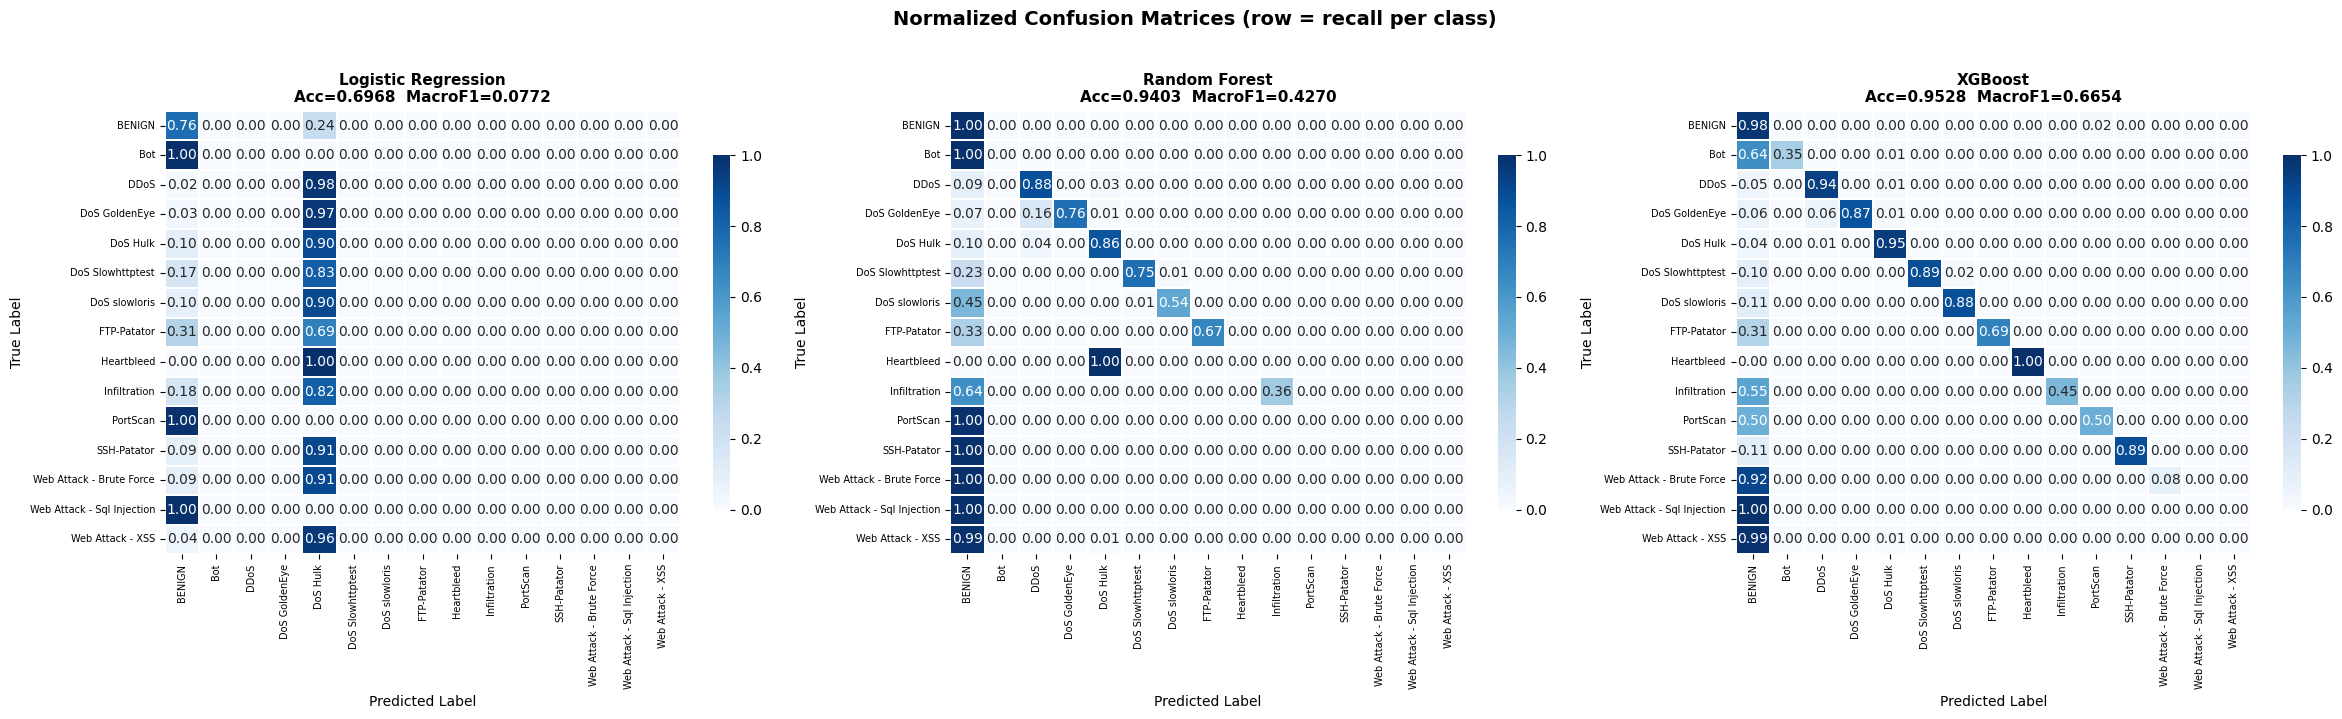

In [8]:
if sections_cfg.run_multiclass:
    show_confusion_matrices(results, y_test, class_names, 'Normalized Confusion Matrices (row = recall per class)')

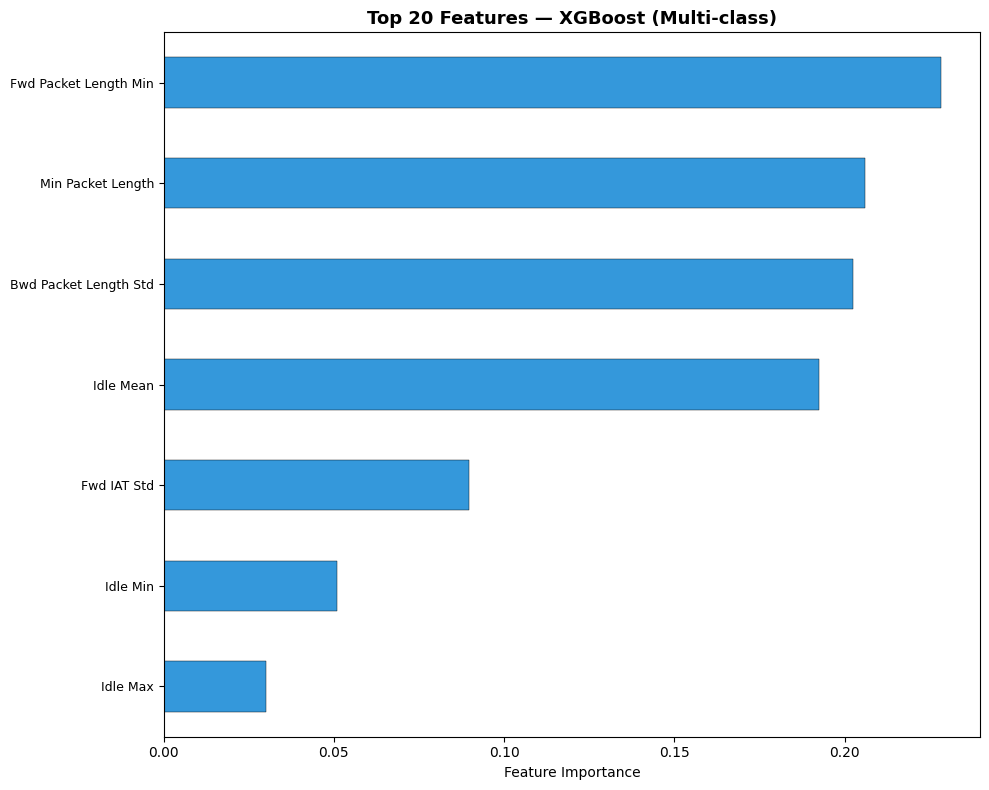

In [9]:
if sections_cfg.run_multiclass:
    show_feature_importance(trained_models, active_feature_cols, '(Multi-class)')

In [10]:
if sections_cfg.run_multiclass:
    s8_summary = show_summary(results, class_names, 'Standard ML Baseline — Summary')

    # Per-class F1
    print("\n\nPer-Class F1 Score Comparison\n")
    per_class_f1 = {}
    for name, res in results.items():
        report = classification_report(y_test, res['y_pred'], target_names=class_names, output_dict=True, zero_division=0)
        per_class_f1[name] = {cls: report[cls]['f1-score'] for cls in class_names}
    f1_df = pd.DataFrame(per_class_f1).round(4)
    f1_df['Best Model'] = f1_df.apply(lambda row: f1_df.columns[row.argmax()], axis=1)
    print(f1_df.to_string())

    weak_classes = f1_df[f1_df.drop(columns='Best Model').max(axis=1) < 0.5]
    if len(weak_classes) > 0:
        print(f"\nClasses where ALL models have F1 < 0.5:")
        for cls in weak_classes.index:
            best_f1 = f1_df.drop(columns='Best Model').loc[cls].max()
            print(f"  {cls}: best F1 = {best_f1:.4f}")

Standard ML Baseline — Summary

              Model Device Accuracy Weighted F1 Macro F1 Train Time (s)
Logistic Regression    GPU   0.6968      0.7199   0.0772            0.6
      Random Forest    GPU   0.9403      0.9210   0.4270           21.7
            XGBoost    GPU   0.9528      0.9515   0.6654           15.6


Per-Class F1 Score Comparison

                            Logistic Regression  Random Forest  XGBoost           Best Model
BENIGN                                   0.8400         0.9683   0.9728              XGBoost
Bot                                      0.0000         0.0000   0.5018              XGBoost
DDoS                                     0.0000         0.8893   0.9390              XGBoost
DoS GoldenEye                            0.0000         0.8111   0.9027              XGBoost
DoS Hulk                                 0.3186         0.9134   0.9555              XGBoost
DoS Slowhttptest                         0.0000         0.7937   0.8977              XGBo

---
## Binary Classification Baseline

- **Dataset:** ML dataset
- **Split:** 70/30 stratified random (train/test)
- **Prediction:** Binary (BENIGN vs ATTACK)
- **Balanced:** No (original class distribution)

In [11]:
if sections_cfg.run_binary:
    print("=" * 70)
    print("Binary Classification Baseline")
    print("=" * 70)

    df_s9 = ml_df if data_cfg.use_ml_dataset else tl_df
    y_bin = (df_s9['Label'] != 'BENIGN').astype(int).values
    X = df_s9[active_feature_cols].values
    bin_class_names = np.array(['BENIGN', 'ATTACK'])

    print(f"BENIGN: {(y_bin == 0).sum():,}, ATTACK: {(y_bin == 1).sum():,}")

    X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
        X, y_bin, test_size=split_cfg.test_size, random_state=split_cfg.random_state, stratify=y_bin
    )

    scaler_bin = RobustScaler()
    X_train_bin_scaled = scaler_bin.fit_transform(X_train_bin)
    X_test_bin_scaled = scaler_bin.transform(X_test_bin)

    bin_classifiers = build_classifiers(binary=True)
    bin_results, bin_trained_models = train_and_evaluate(
        bin_classifiers, X_train_bin, y_train_bin, X_test_bin, y_test_bin,
        X_train_bin_scaled, X_test_bin_scaled, bin_class_names, "binary"
    )
else:
    print("Binary Classification Baseline DISABLED.")

Binary Classification Baseline
BENIGN: 2,095,057, ATTACK: 425,741
Training Logistic Regression [GPU]...
  Done in 0.0s — Accuracy: 0.7109, Weighted F1: 0.7448, Macro F1: 0.6314

Training Random Forest [GPU]...
  Done in 22.4s — Accuracy: 0.9493, Weighted F1: 0.9482, Macro F1: 0.9059

Training XGBoost [GPU]...
  Done in 1.3s — Accuracy: 0.9542, Weighted F1: 0.9538, Macro F1: 0.9171

All binary models trained.


Classification Report — Logistic Regression
              precision    recall  f1-score   support

      BENIGN     0.9279    0.7072    0.8026    628518
      ATTACK     0.3361    0.7294    0.4601    127722

    accuracy                         0.7109    756240
   macro avg     0.6320    0.7183    0.6314    756240
weighted avg     0.8279    0.7109    0.7448    756240


Classification Report — Random Forest
              precision    recall  f1-score   support

      BENIGN     0.9601    0.9797    0.9698    628518
      ATTACK     0.8891    0.7995    0.8419    127722

    accuracy                         0.9493    756240
   macro avg     0.9246    0.8896    0.9059    756240
weighted avg     0.9481    0.9493    0.9482    756240


Classification Report — XGBoost
              precision    recall  f1-score   support

      BENIGN     0.9686    0.9766    0.9726    628518
      ATTACK     0.8798    0.8441    0.8616    127722

    accuracy                         0.9542    756240
   macro avg

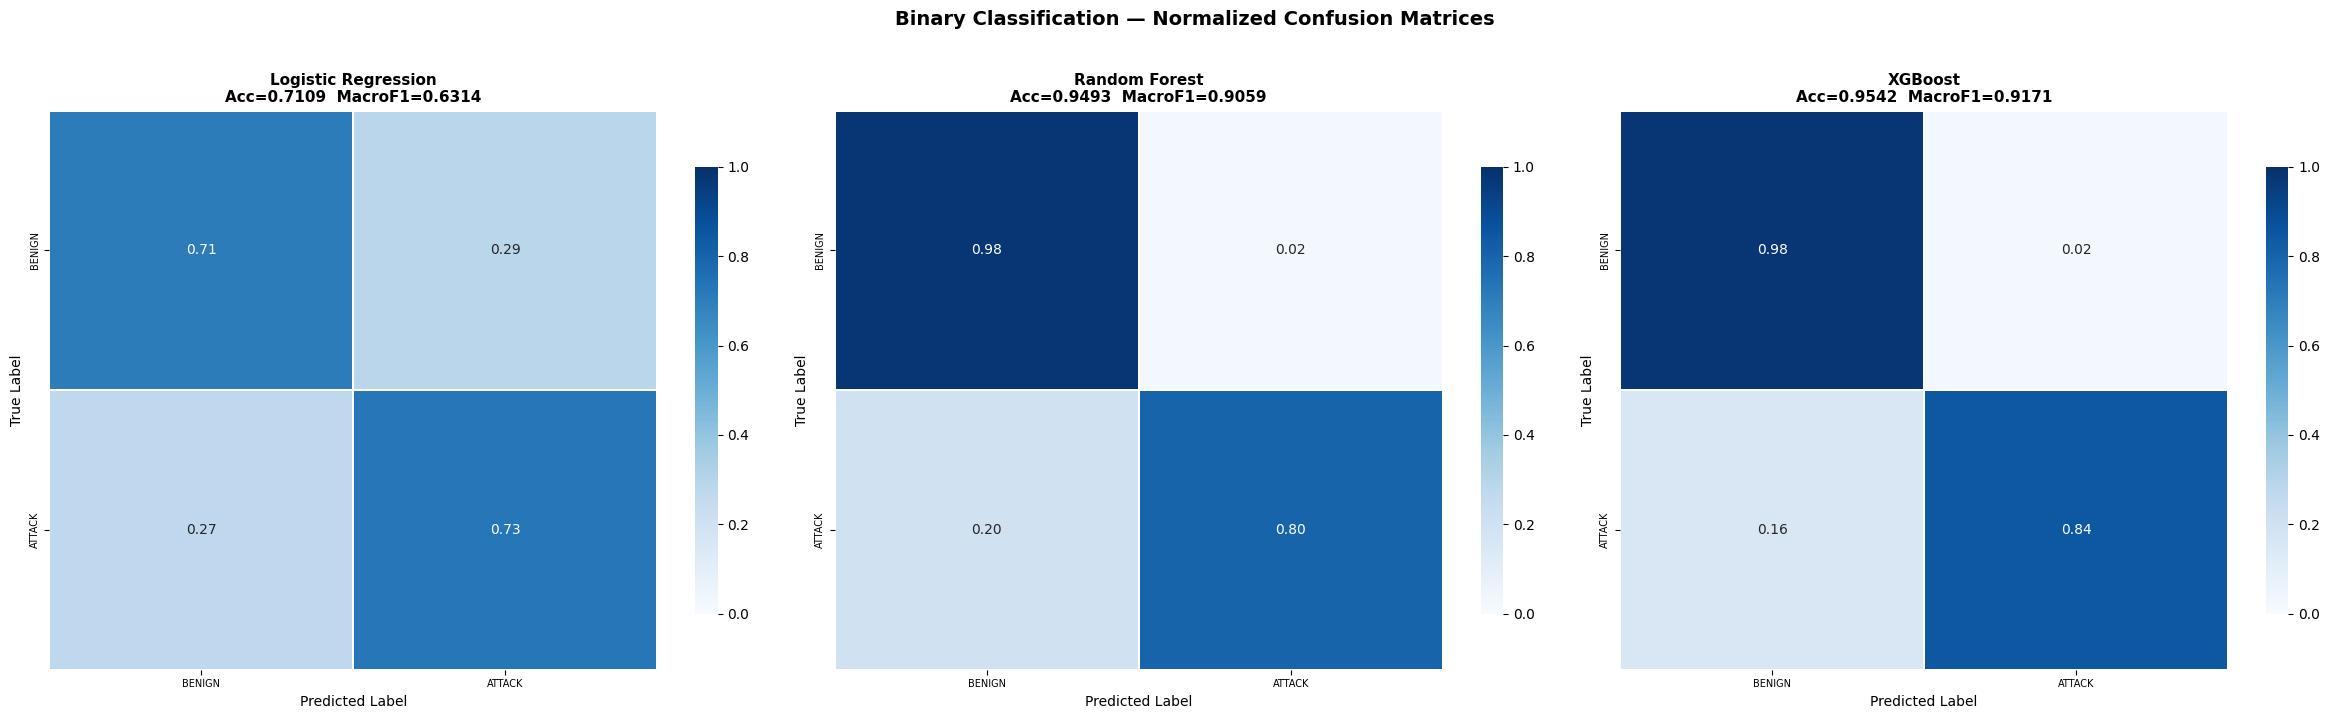

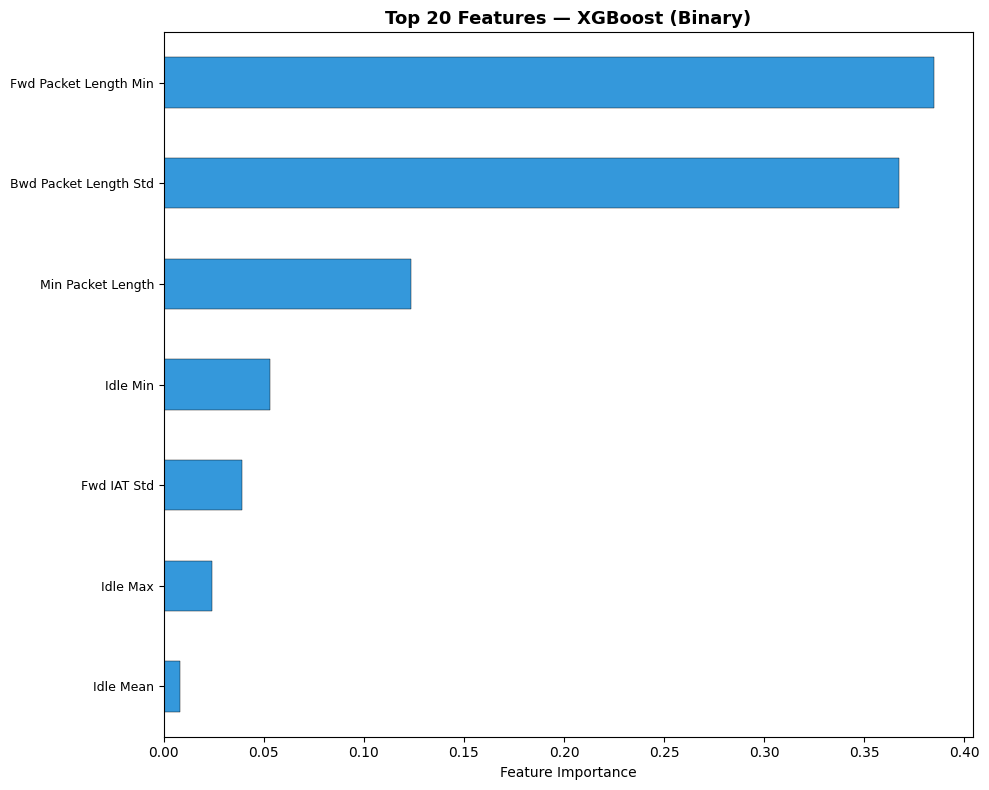

Binary Classification Baseline — Summary

              Model Device Accuracy Weighted F1 Macro F1 Train Time (s)
Logistic Regression    GPU   0.7109      0.7448   0.6314            0.0
      Random Forest    GPU   0.9493      0.9482   0.9059           22.4
            XGBoost    GPU   0.9542      0.9538   0.9171            1.3


In [12]:
if sections_cfg.run_binary:
    show_reports(bin_results, y_test_bin, bin_class_names)
    show_confusion_matrices(bin_results, y_test_bin, bin_class_names, 'Binary Classification — Normalized Confusion Matrices')
    show_feature_importance(bin_trained_models, active_feature_cols, '(Binary)')
    s9_summary = show_summary(bin_results, bin_class_names, 'Binary Classification Baseline — Summary')

---
## Balanced Binary Classification

- **Dataset:** ML dataset
- **Split:** 70/30 stratified random (train/test)
- **Prediction:** Binary (BENIGN vs ATTACK)
- **Balanced:** Yes — 50/50 BENIGN/ATTACK via undersampling

In [13]:
if sections_cfg.run_balanced:
    print("=" * 70)
    print("Balanced Binary Classification")
    print("=" * 70)

    df_s10 = ml_df if data_cfg.use_ml_dataset else tl_df
    df_s10 = df_s10.copy()
    df_s10['binary_label'] = (df_s10['Label'] != 'BENIGN').astype(int)

    attack_df = df_s10[df_s10['binary_label'] == 1]
    benign_df = df_s10[df_s10['binary_label'] == 0]
    n_attack = len(attack_df)
    benign_sampled = benign_df.sample(n=n_attack, random_state=split_cfg.random_state)
    balanced_df = pd.concat([benign_sampled, attack_df], ignore_index=True)

    print(f"Balanced: BENIGN={len(benign_sampled):,}, ATTACK={n_attack:,}, Total={len(balanced_df):,}")

    X_bal = balanced_df[active_feature_cols].values
    y_bal = balanced_df['binary_label'].values
    bal_class_names = np.array(['BENIGN', 'ATTACK'])

    X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
        X_bal, y_bal, test_size=split_cfg.test_size, random_state=split_cfg.random_state, stratify=y_bal
    )

    scaler_bal = RobustScaler()
    X_train_bal_scaled = scaler_bal.fit_transform(X_train_bal)
    X_test_bal_scaled = scaler_bal.transform(X_test_bal)

    bal_classifiers = build_classifiers(binary=True)
    bal_results, bal_trained_models = train_and_evaluate(
        bal_classifiers, X_train_bal, y_train_bal, X_test_bal, y_test_bal,
        X_train_bal_scaled, X_test_bal_scaled, bal_class_names, "balanced binary"
    )
else:
    print("Balanced Binary Classification DISABLED.")

Balanced Binary Classification
Balanced: BENIGN=425,741, ATTACK=425,741, Total=851,482
Training Logistic Regression [GPU]...
  Done in 0.1s — Accuracy: 0.7017, Weighted F1: 0.6984, Macro F1: 0.6984

Training Random Forest [GPU]...
  Done in 5.4s — Accuracy: 0.9131, Weighted F1: 0.9128, Macro F1: 0.9128

Training XGBoost [GPU]...
  Done in 0.7s — Accuracy: 0.9173, Weighted F1: 0.9171, Macro F1: 0.9171

All balanced binary models trained.


Classification Report — Logistic Regression
              precision    recall  f1-score   support

      BENIGN     0.6665    0.8076    0.7303    127723
      ATTACK     0.7559    0.5958    0.6664    127722

    accuracy                         0.7017    255445
   macro avg     0.7112    0.7017    0.6984    255445
weighted avg     0.7112    0.7017    0.6984    255445


Classification Report — Random Forest
              precision    recall  f1-score   support

      BENIGN     0.8745    0.9646    0.9173    127723
      ATTACK     0.9605    0.8616    0.9084    127722

    accuracy                         0.9131    255445
   macro avg     0.9175    0.9131    0.9128    255445
weighted avg     0.9175    0.9131    0.9128    255445


Classification Report — XGBoost
              precision    recall  f1-score   support

      BENIGN     0.8796    0.9670    0.9212    127723
      ATTACK     0.9633    0.8676    0.9130    127722

    accuracy                         0.9173    255445
   macro avg

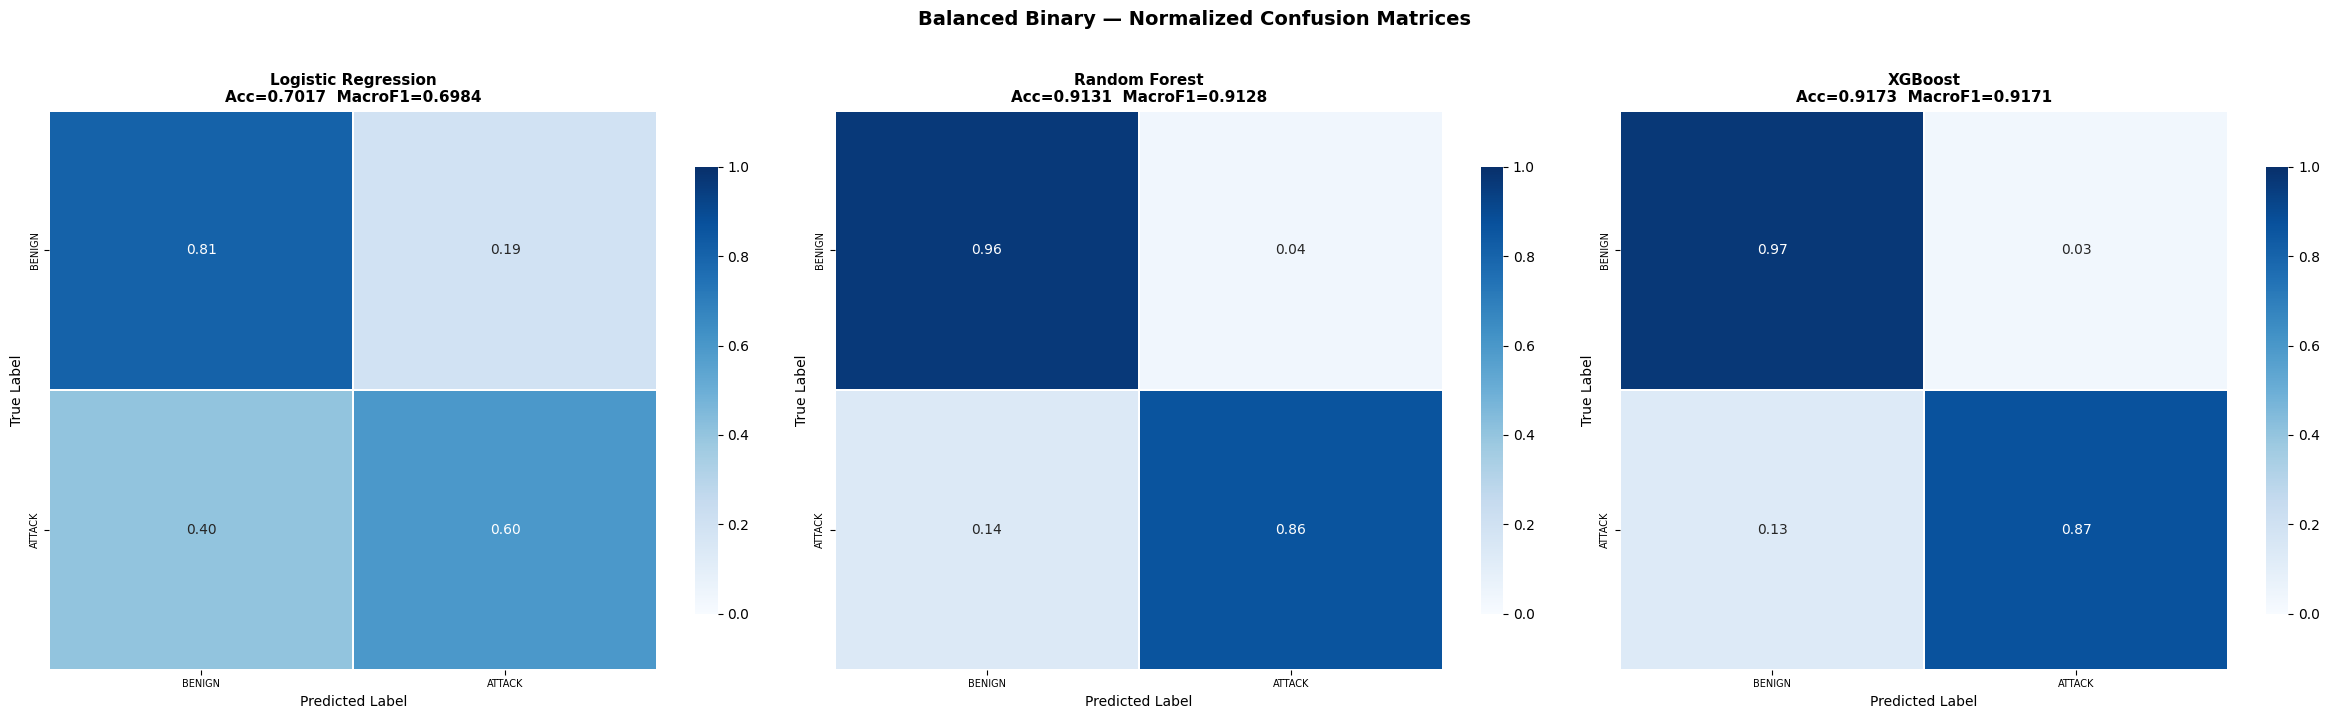

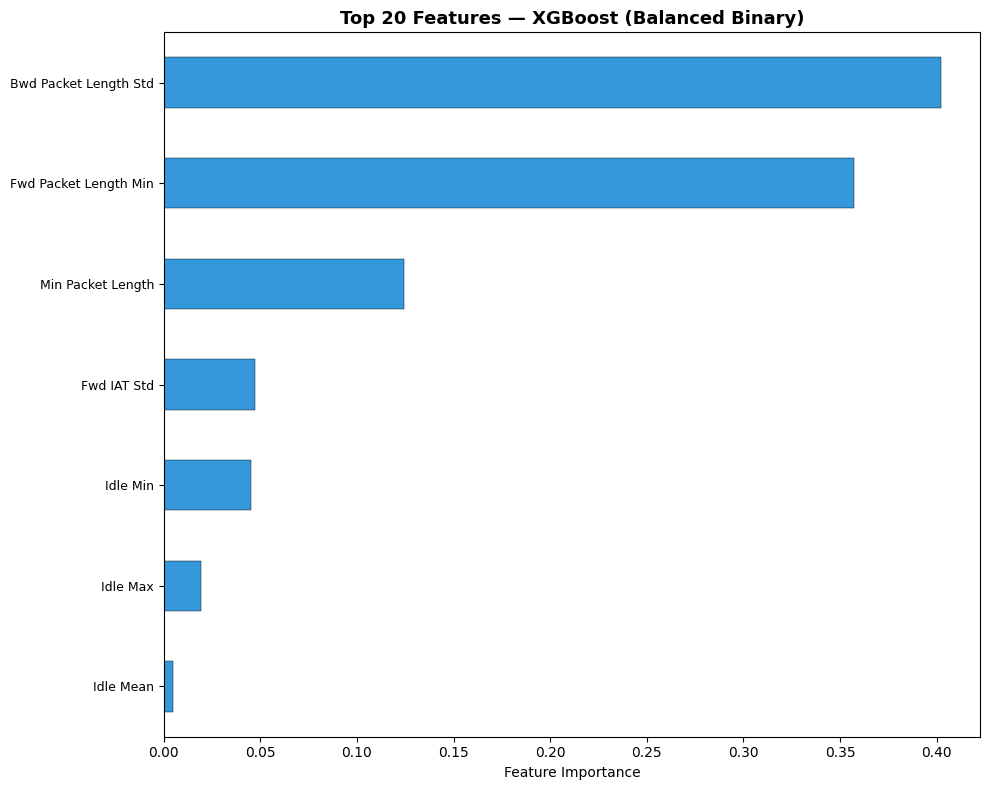

Balanced Binary Classification — Summary

              Model Device Accuracy Weighted F1 Macro F1 Train Time (s)
Logistic Regression    GPU   0.7017      0.6984   0.6984            0.1
      Random Forest    GPU   0.9131      0.9128   0.9128            5.4
            XGBoost    GPU   0.9173      0.9171   0.9171            0.7


In [14]:
if sections_cfg.run_balanced:
    show_reports(bal_results, y_test_bal, bal_class_names)
    show_confusion_matrices(bal_results, y_test_bal, bal_class_names, 'Balanced Binary — Normalized Confusion Matrices')
    show_feature_importance(bal_trained_models, active_feature_cols, '(Balanced Binary)')
    s10_summary = show_summary(bal_results, bal_class_names, 'Balanced Binary Classification — Summary')

---
## Temporal Split — Mon–Thu Train / Friday Test

- **Dataset:** TL dataset (requires timestamps)
- **Split:** Temporal — Mon–Thu train / Friday test
- **Prediction:** Binary (BENIGN vs ATTACK)
- **Balanced:** Yes — training set balanced via undersampling

In [15]:
if sections_cfg.run_temporal:
    print("=" * 70)
    print("Temporal Split (Mon-Thu / Friday)")
    print("=" * 70)

    # Parse timestamps and extract date
    tl_df['Timestamp_parsed'] = pd.to_datetime(tl_df['Timestamp'], format='mixed', dayfirst=True)
    tl_df['date'] = tl_df['Timestamp_parsed'].dt.date

    print(f"Timestamp range: {tl_df['Timestamp_parsed'].min()} -> {tl_df['Timestamp_parsed'].max()}")
    print("\nRows per day:")
    for d, n in tl_df.groupby('date').size().items():
        print(f"  {d} ({pd.Timestamp(d).strftime('%A')}): {n:,}")

    # Deduplicate on feature columns + label
    ts_dedup_cols = active_feature_cols + ['Label']
    ts_before = len(tl_df)
    tl_df_dedup = tl_df.drop_duplicates(subset=ts_dedup_cols, keep='first').copy()
    print(f"\nDeduplication: {ts_before:,} -> {len(tl_df_dedup):,}")

    tl_df_dedup['binary_label'] = (tl_df_dedup['Label'] != 'BENIGN').astype(int)

    # Split by day
    ts_train_mask = tl_df_dedup['date'] < datetime.date(2017, 7, 7)
    ts_test_mask = tl_df_dedup['date'] == datetime.date(2017, 7, 7)

    ts_train_full = tl_df_dedup[ts_train_mask]
    ts_test_full = tl_df_dedup[ts_test_mask]

    print(f"\nTrain (Mon-Thu): {len(ts_train_full):,} (ATTACK: {(ts_train_full['binary_label']==1).sum():,})")
    print(f"Test (Friday):   {len(ts_test_full):,} (ATTACK: {(ts_test_full['binary_label']==1).sum():,})")

    # Balance training set
    ts_train_attack = ts_train_full[ts_train_full['binary_label'] == 1]
    ts_train_benign = ts_train_full[ts_train_full['binary_label'] == 0]
    ts_train_benign_sampled = ts_train_benign.sample(n=len(ts_train_attack), random_state=split_cfg.random_state)
    ts_train_balanced = pd.concat([ts_train_benign_sampled, ts_train_attack], ignore_index=True)

    print(f"Balanced train: {len(ts_train_balanced):,}")

    X_train_ts = ts_train_balanced[active_feature_cols].values
    y_train_ts = ts_train_balanced['binary_label'].values
    X_test_ts = ts_test_full[active_feature_cols].values
    y_test_ts = ts_test_full['binary_label'].values
    ts_class_names = np.array(['BENIGN', 'ATTACK'])

    scaler_ts = RobustScaler()
    X_train_ts_scaled = scaler_ts.fit_transform(X_train_ts)
    X_test_ts_scaled = scaler_ts.transform(X_test_ts)

    ts_classifiers = build_classifiers(binary=True)
    ts_results, ts_trained_models = train_and_evaluate(
        ts_classifiers, X_train_ts, y_train_ts, X_test_ts, y_test_ts,
        X_train_ts_scaled, X_test_ts_scaled, ts_class_names, "temporal-split"
    )
else:
    print("Temporal Split DISABLED.")
    tl_df_dedup = None

Temporal Split (Mon-Thu / Friday)
Timestamp range: 2017-07-03 01:00:01 -> 2017-07-07 12:59:00

Rows per day:
  2017-07-03 (Monday): 529,450
  2017-07-04 (Tuesday): 445,641
  2017-07-05 (Wednesday): 691,390
  2017-07-06 (Thursday): 458,483
  2017-07-07 (Friday): 702,713

Deduplication: 2,827,677 -> 899,917

Train (Mon-Thu): 653,387 (ATTACK: 72,636)
Test (Friday):   246,530 (ATTACK: 102,160)
Balanced train: 145,272
Training Logistic Regression [GPU]...
  Done in 0.2s — Accuracy: 0.7440, Weighted F1: 0.7326, Macro F1: 0.7179

Training Random Forest [GPU]...
  Done in 1.2s — Accuracy: 0.7898, Weighted F1: 0.7748, Macro F1: 0.7605

Training XGBoost [GPU]...
  Done in 0.3s — Accuracy: 0.7772, Weighted F1: 0.7616, Macro F1: 0.7465

All temporal-split models trained.


Classification Report — Logistic Regression
              precision    recall  f1-score   support

      BENIGN     0.7294    0.8946    0.8036    144370
      ATTACK     0.7810    0.5310    0.6322    102160

    accuracy                         0.7440    246530
   macro avg     0.7552    0.7128    0.7179    246530
weighted avg     0.7508    0.7440    0.7326    246530


Classification Report — Random Forest
              precision    recall  f1-score   support

      BENIGN     0.7456    0.9730    0.8443    144370
      ATTACK     0.9330    0.5309    0.6767    102160

    accuracy                         0.7898    246530
   macro avg     0.8393    0.7520    0.7605    246530
weighted avg     0.8233    0.7898    0.7748    246530


Classification Report — XGBoost
              precision    recall  f1-score   support

      BENIGN     0.7379    0.9608    0.8347    144370
      ATTACK     0.9034    0.5178    0.6583    102160

    accuracy                         0.7772    246530
   macro avg

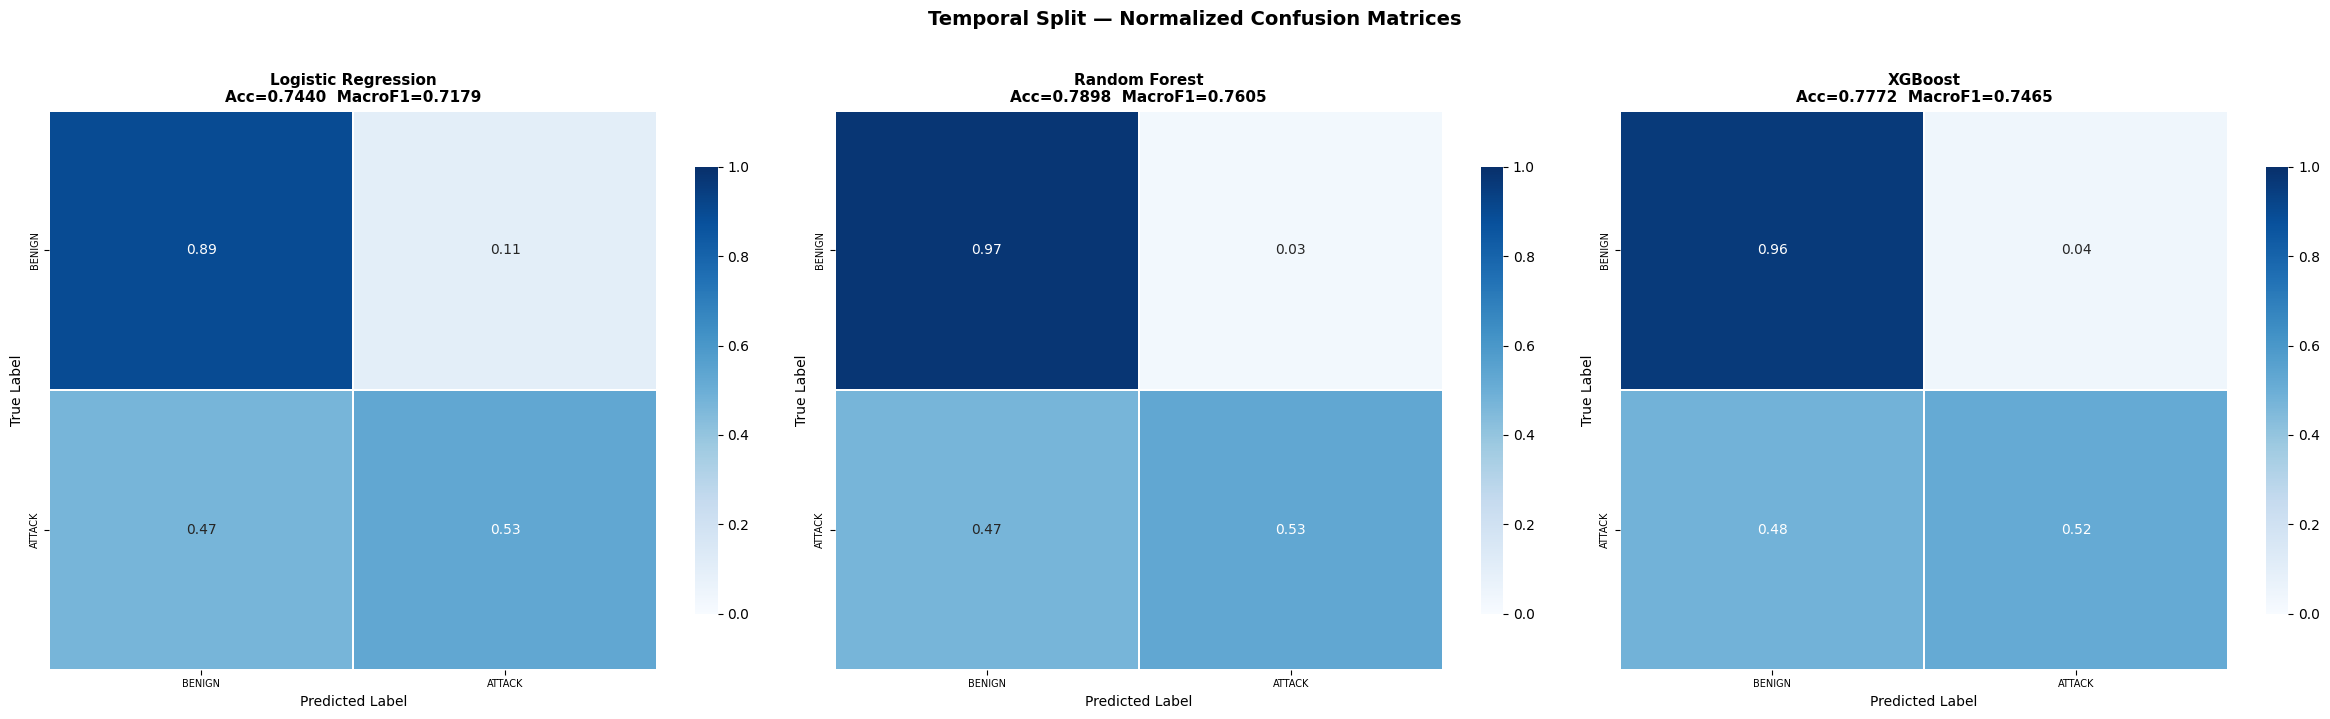

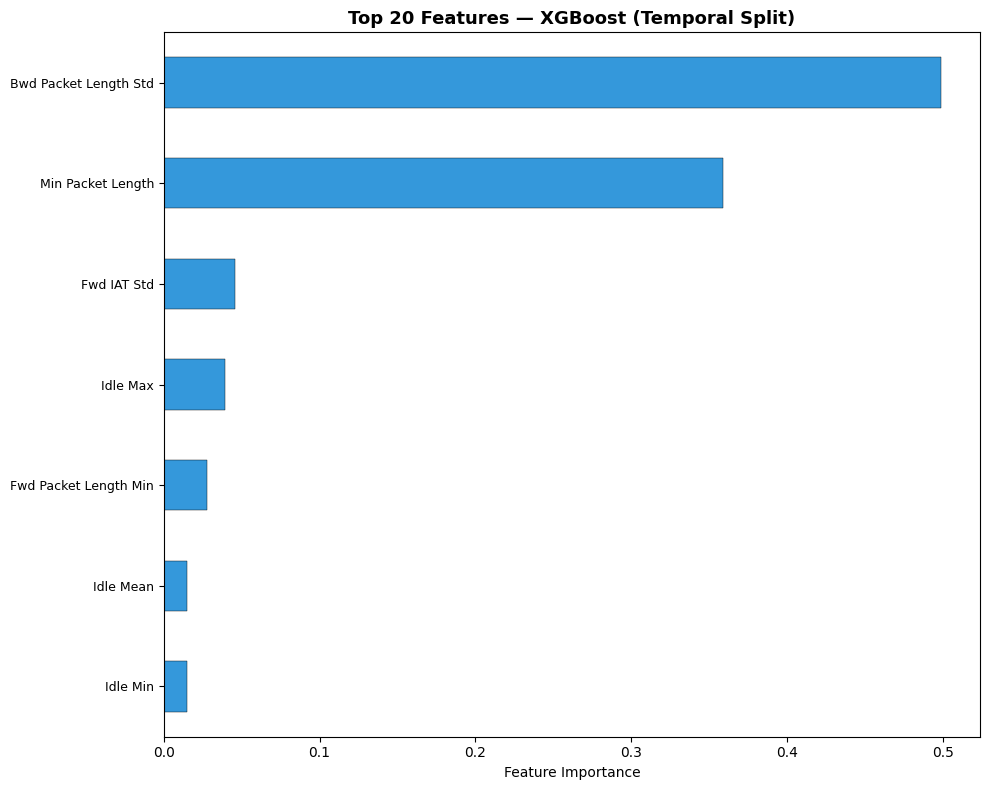

Temporal Split — Summary

              Model Device Accuracy Weighted F1 Macro F1 Train Time (s)
Logistic Regression    GPU   0.7440      0.7326   0.7179            0.2
      Random Forest    GPU   0.7898      0.7748   0.7605            1.2
            XGBoost    GPU   0.7772      0.7616   0.7465            0.3


In [16]:
if sections_cfg.run_temporal:
    show_reports(ts_results, y_test_ts, ts_class_names)
    show_confusion_matrices(ts_results, y_test_ts, ts_class_names, 'Temporal Split — Normalized Confusion Matrices')
    show_feature_importance(ts_trained_models, active_feature_cols, '(Temporal Split)')
    s11_summary = show_summary(ts_results, ts_class_names, 'Temporal Split — Summary')

---
## Day-Stratified Split

- **Dataset:** TL dataset (requires timestamps)
- **Split:** 70/30 stratified per day (train/test)
- **Prediction:** Binary (BENIGN vs ATTACK)
- **Balanced:** Yes — training set balanced via undersampling

In [17]:
if sections_cfg.run_day_stratified:
    print("=" * 70)
    print("Day-Stratified Split")
    print("=" * 70)

    # Ensure tl_df_dedup exists
    if tl_df_dedup is None:
        tl_df['Timestamp_parsed'] = pd.to_datetime(tl_df['Timestamp'], format='mixed', dayfirst=True)
        tl_df['date'] = tl_df['Timestamp_parsed'].dt.date
        ts_dedup_cols = active_feature_cols + ['Label']
        tl_df_dedup = tl_df.drop_duplicates(subset=ts_dedup_cols, keep='first').copy()
        tl_df_dedup['binary_label'] = (tl_df_dedup['Label'] != 'BENIGN').astype(int)

    ds_train_parts, ds_test_parts = [], []

    print("Per-day stratified 70/30 split:\n")
    for day, day_df in tl_df_dedup.groupby('date'):
        day_name = pd.Timestamp(day).strftime('%A %b %d')
        n_benign = (day_df['binary_label'] == 0).sum()
        n_attack = (day_df['binary_label'] == 1).sum()

        if n_attack < 2 or n_benign < 2:
            ds_train_parts.append(day_df)
            print(f"  {day_name}: {len(day_df):>8,} rows -> all to train")
            continue

        day_train, day_test = train_test_split(
            day_df, test_size=split_cfg.test_size, random_state=split_cfg.random_state, stratify=day_df['binary_label']
        )
        ds_train_parts.append(day_train)
        ds_test_parts.append(day_test)
        print(f"  {day_name}: {len(day_df):>8,} rows -> train={len(day_train):,}, test={len(day_test):,}")

    ds_train_full = pd.concat(ds_train_parts, ignore_index=True)
    ds_test_full = pd.concat(ds_test_parts, ignore_index=True)

    # Balance
    ds_train_attack = ds_train_full[ds_train_full['binary_label'] == 1]
    ds_train_benign = ds_train_full[ds_train_full['binary_label'] == 0]
    ds_train_benign_sampled = ds_train_benign.sample(n=len(ds_train_attack), random_state=split_cfg.random_state)
    ds_train_balanced = pd.concat([ds_train_benign_sampled, ds_train_attack], ignore_index=True)

    print(f"\nBalanced train: {len(ds_train_balanced):,}, Test: {len(ds_test_full):,}")

    X_train_ds = ds_train_balanced[active_feature_cols].values
    y_train_ds = ds_train_balanced['binary_label'].values
    X_test_ds = ds_test_full[active_feature_cols].values
    y_test_ds = ds_test_full['binary_label'].values
    ds_class_names = np.array(['BENIGN', 'ATTACK'])

    scaler_ds = RobustScaler()
    X_train_ds_scaled = scaler_ds.fit_transform(X_train_ds)
    X_test_ds_scaled = scaler_ds.transform(X_test_ds)

    ds_classifiers = build_classifiers(binary=True)
    ds_results, ds_trained_models = train_and_evaluate(
        ds_classifiers, X_train_ds, y_train_ds, X_test_ds, y_test_ds,
        X_train_ds_scaled, X_test_ds_scaled, ds_class_names, "day-stratified"
    )
else:
    print("Day-Stratified Split DISABLED.")

Day-Stratified Split
Per-day stratified 70/30 split:

  Monday Jul 03:  179,809 rows -> all to train
  Tuesday Jul 04:  142,402 rows -> train=99,681, test=42,721
  Wednesday Jul 05:  202,888 rows -> train=142,021, test=60,867
  Thursday Jul 06:  128,288 rows -> train=89,801, test=38,487
  Friday Jul 07:  246,530 rows -> train=172,571, test=73,959

Balanced train: 244,714, Test: 216,034
Training Logistic Regression [GPU]...
  Done in 0.1s — Accuracy: 0.8248, Weighted F1: 0.8233, Macro F1: 0.7578

Training Random Forest [GPU]...
  Done in 2.2s — Accuracy: 0.9642, Weighted F1: 0.9647, Macro F1: 0.9527

Training XGBoost [GPU]...
  Done in 0.4s — Accuracy: 0.9686, Weighted F1: 0.9690, Macro F1: 0.9584

All day-stratified models trained.


Classification Report — Logistic Regression
              precision    recall  f1-score   support

      BENIGN     0.8787    0.8917    0.8852    163595
      ATTACK     0.6458    0.6159    0.6305     52439

    accuracy                         0.8248    216034
   macro avg     0.7623    0.7538    0.7578    216034
weighted avg     0.8222    0.8248    0.8233    216034


Classification Report — Random Forest
              precision    recall  f1-score   support

      BENIGN     0.9900    0.9625    0.9760    163595
      ATTACK     0.8922    0.9697    0.9294     52439

    accuracy                         0.9642    216034
   macro avg     0.9411    0.9661    0.9527    216034
weighted avg     0.9663    0.9642    0.9647    216034


Classification Report — XGBoost
              precision    recall  f1-score   support

      BENIGN     0.9917    0.9666    0.9790    163595
      ATTACK     0.9034    0.9748    0.9378     52439

    accuracy                         0.9686    216034
   macro avg

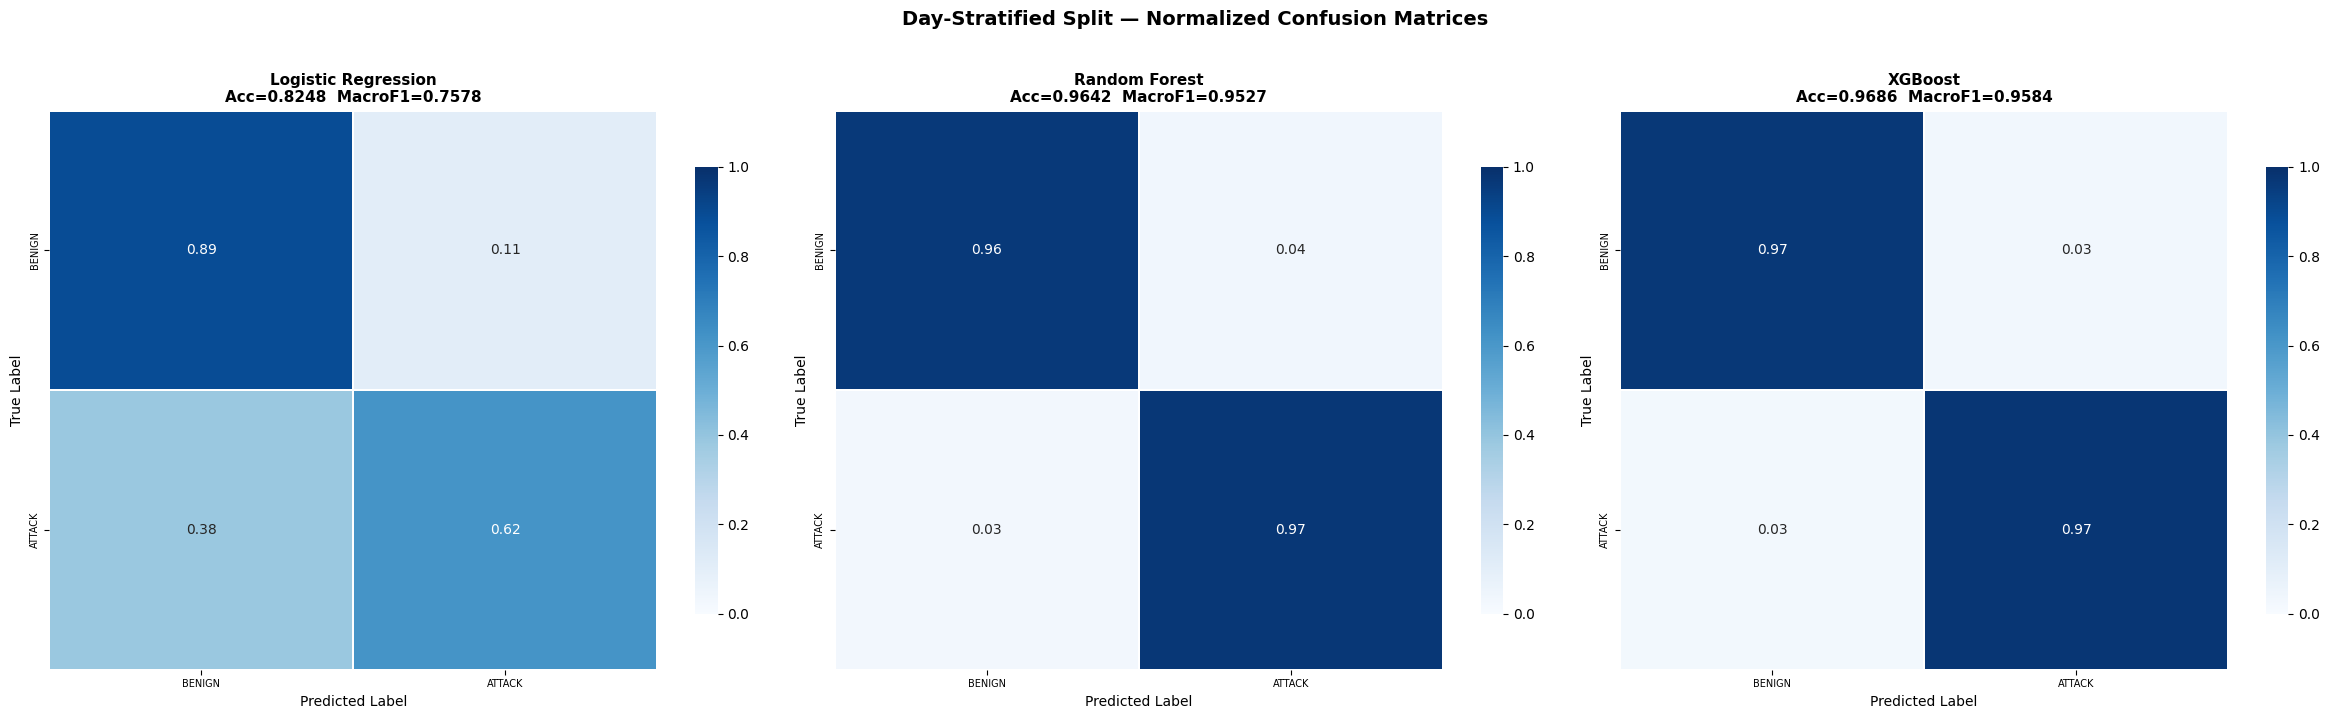

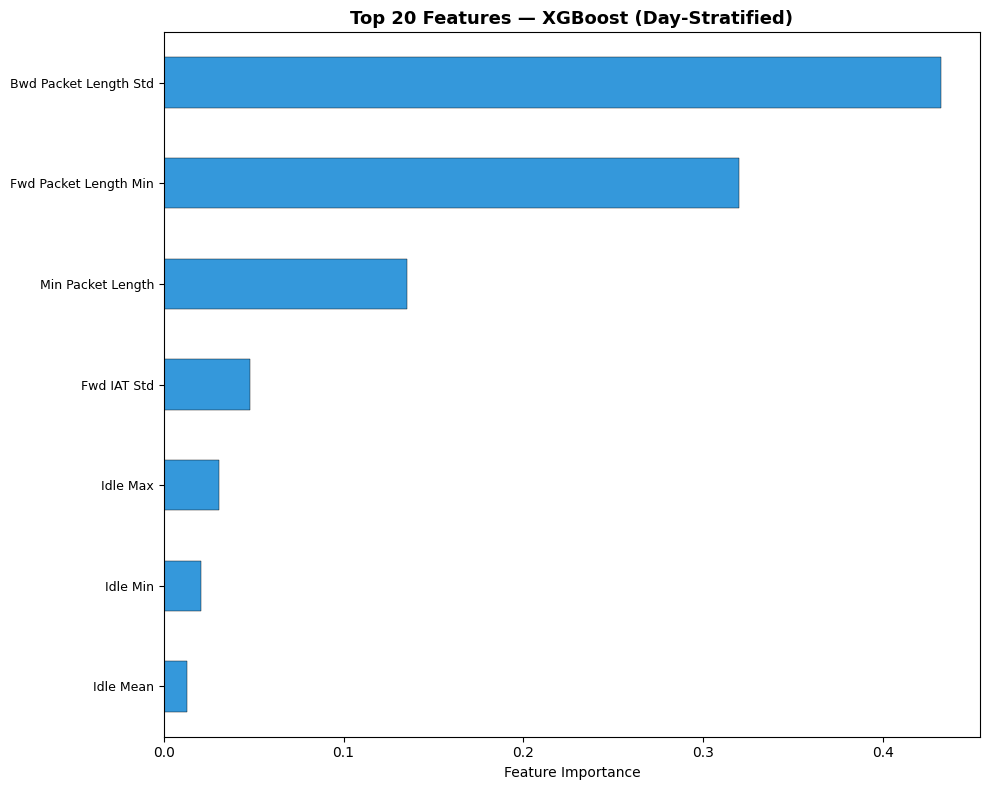

Day-Stratified Split — Summary

              Model Device Accuracy Weighted F1 Macro F1 Train Time (s)
Logistic Regression    GPU   0.8248      0.8233   0.7578            0.1
      Random Forest    GPU   0.9642      0.9647   0.9527            2.2
            XGBoost    GPU   0.9686      0.9690   0.9584            0.4


In [18]:
if sections_cfg.run_day_stratified:
    show_reports(ds_results, y_test_ds, ds_class_names)
    show_confusion_matrices(ds_results, y_test_ds, ds_class_names, 'Day-Stratified Split — Normalized Confusion Matrices')
    show_feature_importance(ds_trained_models, active_feature_cols, '(Day-Stratified)')
    s12_summary = show_summary(ds_results, ds_class_names, 'Day-Stratified Split — Summary')

---
## Chronological Split

- **Dataset:** TL dataset (requires timestamps)
- **Split:** 70/15/15 chronological per day (train/val/test)
- **Prediction:** Binary (BENIGN vs ATTACK)
- **Balanced:** Yes — training set balanced via undersampling
- **Early stopping:** XGBoost uses validation set for early stopping

In [19]:
if sections_cfg.run_chronological:
    print("=" * 70)
    print("Chronological Split (70/15/15 per day)")
    print("=" * 70)

    if tl_df_dedup is None:
        tl_df['Timestamp_parsed'] = pd.to_datetime(tl_df['Timestamp'], format='mixed', dayfirst=True)
        tl_df['date'] = tl_df['Timestamp_parsed'].dt.date
        ts_dedup_cols = active_feature_cols + ['Label']
        tl_df_dedup = tl_df.drop_duplicates(subset=ts_dedup_cols, keep='first').copy()
        tl_df_dedup['binary_label'] = (tl_df_dedup['Label'] != 'BENIGN').astype(int)

    cs_train_parts, cs_val_parts, cs_test_parts = [], [], []

    print("Per-day chronological 70/15/15 split:\n")
    for day, day_df in tl_df_dedup.groupby('date'):
        day_name = pd.Timestamp(day).strftime('%A %b %d')
        day_sorted = day_df.sort_values('Timestamp_parsed').reset_index(drop=True)
        n = len(day_sorted)

        train_end = int(n * 0.70)
        val_end = int(n * 0.85)

        cs_day_train = day_sorted.iloc[:train_end]
        cs_day_val = day_sorted.iloc[train_end:val_end]
        cs_day_test = day_sorted.iloc[val_end:]

        cs_train_parts.append(cs_day_train)
        cs_val_parts.append(cs_day_val)
        cs_test_parts.append(cs_day_test)

        print(f"  {day_name}: {n:>8,} -> train={len(cs_day_train):,}, val={len(cs_day_val):,}, test={len(cs_day_test):,}")

    cs_train_full = pd.concat(cs_train_parts, ignore_index=True)
    cs_val_full = pd.concat(cs_val_parts, ignore_index=True)
    cs_test_full = pd.concat(cs_test_parts, ignore_index=True)

    # Balance
    cs_train_attack = cs_train_full[cs_train_full['binary_label'] == 1]
    cs_train_benign = cs_train_full[cs_train_full['binary_label'] == 0]
    cs_train_benign_sampled = cs_train_benign.sample(n=len(cs_train_attack), random_state=split_cfg.random_state)
    cs_train_balanced = pd.concat([cs_train_benign_sampled, cs_train_attack], ignore_index=True)

    print(f"\nBalanced train: {len(cs_train_balanced):,}, Val: {len(cs_val_full):,}, Test: {len(cs_test_full):,}")

    X_train_cs = cs_train_balanced[active_feature_cols].values
    y_train_cs = cs_train_balanced['binary_label'].values
    X_val_cs = cs_val_full[active_feature_cols].values
    y_val_cs = cs_val_full['binary_label'].values
    X_test_cs = cs_test_full[active_feature_cols].values
    y_test_cs = cs_test_full['binary_label'].values
    cs_class_names = np.array(['BENIGN', 'ATTACK'])

    scaler_cs = RobustScaler()
    X_train_cs_scaled = scaler_cs.fit_transform(X_train_cs)
    X_val_cs_scaled = scaler_cs.transform(X_val_cs)
    X_test_cs_scaled = scaler_cs.transform(X_test_cs)

    cs_classifiers = build_classifiers(binary=True, use_early_stopping=True)
    cs_results, cs_trained_models = train_and_evaluate(
        cs_classifiers, X_train_cs, y_train_cs, X_test_cs, y_test_cs,
        X_train_cs_scaled, X_test_cs_scaled, cs_class_names, "chronological",
        X_val=X_val_cs, y_val=y_val_cs, X_val_scaled=X_val_cs_scaled
    )
else:
    print("Chronological Split DISABLED.")

Chronological Split (70/15/15 per day)
Per-day chronological 70/15/15 split:

  Monday Jul 03:  179,809 -> train=125,866, val=26,971, test=26,972
  Tuesday Jul 04:  142,402 -> train=99,681, val=21,360, test=21,361
  Wednesday Jul 05:  202,888 -> train=142,021, val=30,433, test=30,434
  Thursday Jul 06:  128,288 -> train=89,801, val=19,243, test=19,244
  Friday Jul 07:  246,530 -> train=172,571, val=36,979, test=36,980

Balanced train: 271,944, Val: 134,986, Test: 134,991
Training Logistic Regression [GPU]...
  Done in 0.0s — Accuracy: 0.8970, Weighted F1: 0.9138, Macro F1: 0.7283

Training Random Forest [GPU]...
  Done in 2.3s — Accuracy: 0.9461, Weighted F1: 0.9441, Macro F1: 0.7678

Training XGBoost [GPU]...
  XGBoost stopped at 72 trees
  Done in 0.3s — Accuracy: 0.9536, Weighted F1: 0.9536, Macro F1: 0.8140

All chronological models trained.


Classification Report — Logistic Regression
              precision    recall  f1-score   support

      BENIGN     0.9856    0.9028    0.9424    125974
      ATTACK     0.3754    0.8161    0.5142      9017

    accuracy                         0.8970    134991
   macro avg     0.6805    0.8595    0.7283    134991
weighted avg     0.9449    0.8970    0.9138    134991


Classification Report — Random Forest
              precision    recall  f1-score   support

      BENIGN     0.9662    0.9764    0.9713    125974
      ATTACK     0.6130    0.5229    0.5644      9017

    accuracy                         0.9461    134991
   macro avg     0.7896    0.7496    0.7678    134991
weighted avg     0.9426    0.9461    0.9441    134991


Classification Report — XGBoost
              precision    recall  f1-score   support

      BENIGN     0.9752    0.9751    0.9751    125974
      ATTACK     0.6527    0.6529    0.6528      9017

    accuracy                         0.9536    134991
   macro avg

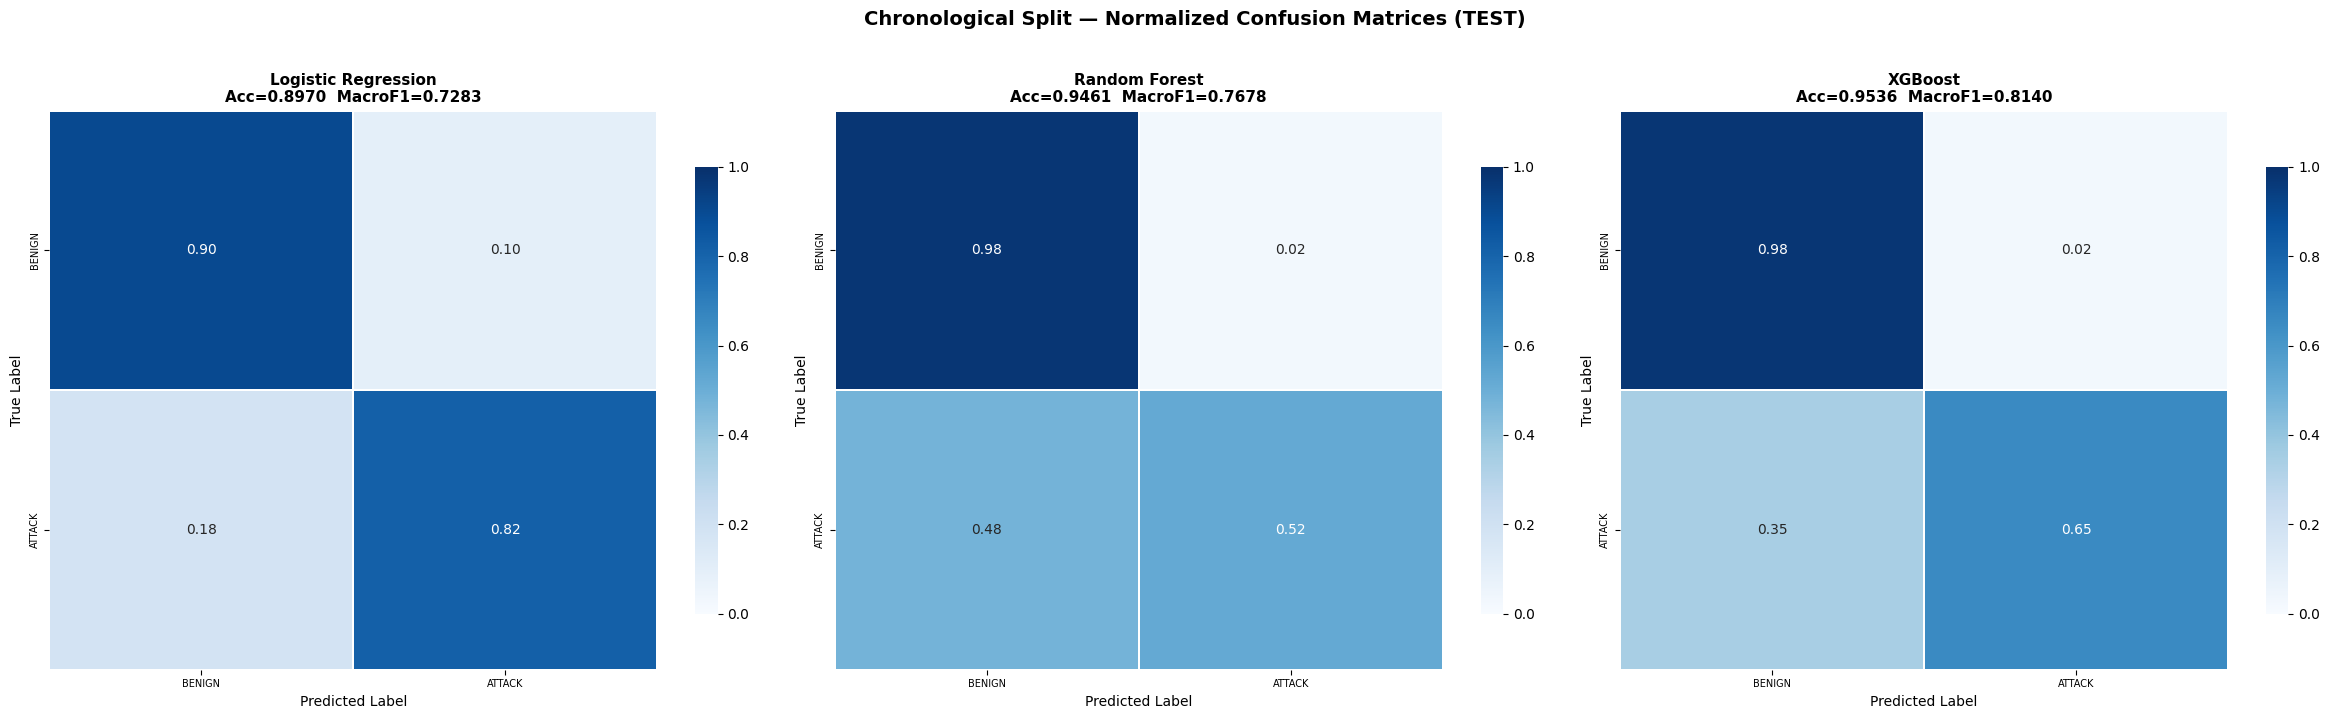

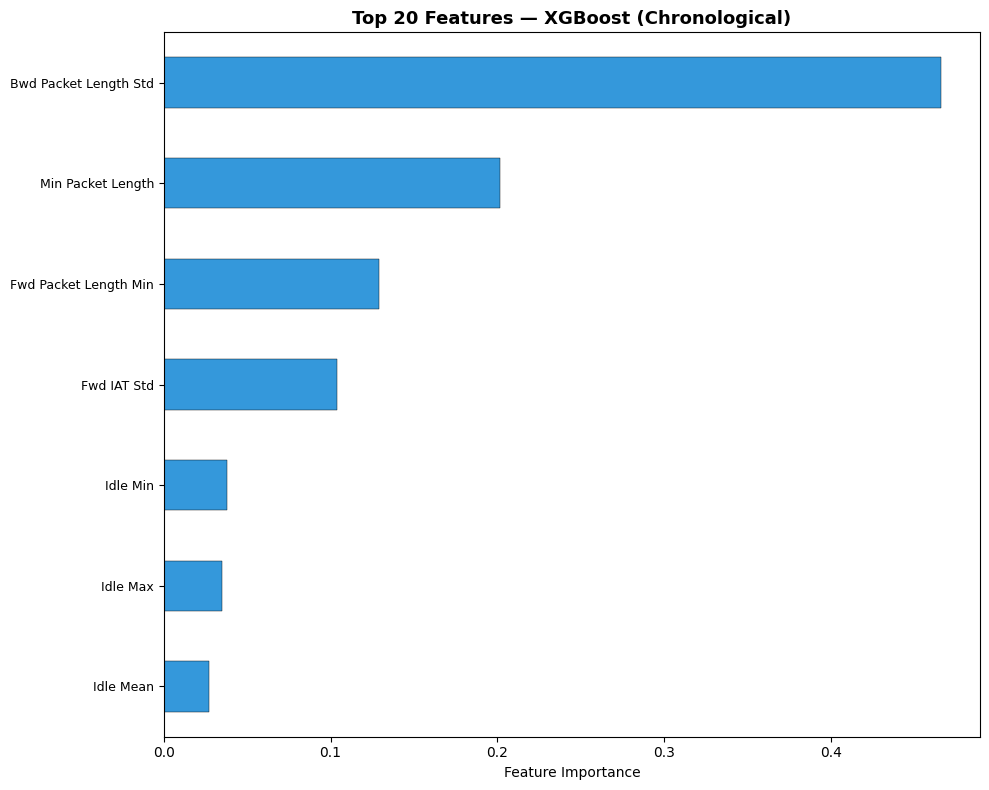

Chronological Split — Summary

              Model Device Accuracy Weighted F1 Macro F1 Train Time (s) Val Accuracy Val Macro F1
Logistic Regression    GPU   0.8970      0.9138   0.7283            0.0       0.8201       0.7335
      Random Forest    GPU   0.9461      0.9441   0.7678            2.3       0.9163       0.8682
            XGBoost    GPU   0.9536      0.9536   0.8140            0.3       0.9153       0.8670


In [20]:
if sections_cfg.run_chronological:
    show_reports(cs_results, y_test_cs, cs_class_names)
    show_confusion_matrices(cs_results, y_test_cs, cs_class_names, 'Chronological Split — Normalized Confusion Matrices (TEST)')
    show_feature_importance(cs_trained_models, active_feature_cols, '(Chronological)')
    s13_summary = show_summary(cs_results, cs_class_names, 'Chronological Split — Summary')

---
## Per-Label Stratified Chronological Split

- **Dataset:** TL dataset (requires timestamps)
- **Split:** 70/15/15 chronological per label (train/val/test)
- **Prediction:** Binary (BENIGN vs ATTACK)
- **Balanced:** Yes — training set balanced via undersampling
- **Early stopping:** XGBoost uses validation set for early stopping
- **Note:** Guarantees all 15 label classes appear in train, val, and test

In [21]:
if sections_cfg.run_label_stratified:
    print("=" * 70)
    print("Per-Label Stratified Chronological Split")
    print("=" * 70)

    if tl_df_dedup is None:
        tl_df['Timestamp_parsed'] = pd.to_datetime(tl_df['Timestamp'], format='mixed', dayfirst=True)
        tl_df['date'] = tl_df['Timestamp_parsed'].dt.date
        ts_dedup_cols = active_feature_cols + ['Label']
        tl_df_dedup = tl_df.drop_duplicates(subset=ts_dedup_cols, keep='first').copy()
        tl_df_dedup['binary_label'] = (tl_df_dedup['Label'] != 'BENIGN').astype(int)

    ls_train_parts, ls_val_parts, ls_test_parts = [], [], []

    print("Per-label chronological 70/15/15 split:\n")
    print(f"{'Label':<30} {'Total':>8} {'Train':>8} {'Val':>8} {'Test':>8}")
    print("-" * 80)

    for label in sorted(tl_df_dedup['Label'].unique()):
        label_df = tl_df_dedup[tl_df_dedup['Label'] == label]
        label_sorted = label_df.sort_values('Timestamp_parsed').reset_index(drop=True)
        n = len(label_sorted)

        train_end = int(n * 0.70)
        val_end = int(n * 0.85)

        ls_label_train = label_sorted.iloc[:train_end]
        ls_label_val = label_sorted.iloc[train_end:val_end]
        ls_label_test = label_sorted.iloc[val_end:]

        ls_train_parts.append(ls_label_train)
        ls_val_parts.append(ls_label_val)
        ls_test_parts.append(ls_label_test)

        print(f"  {label:<28} {n:>8,} {len(ls_label_train):>8,} {len(ls_label_val):>8,} {len(ls_label_test):>8,}")

    ls_train_full = pd.concat(ls_train_parts, ignore_index=True)
    ls_val_full = pd.concat(ls_val_parts, ignore_index=True)
    ls_test_full = pd.concat(ls_test_parts, ignore_index=True)

    print(f"\nTrain: {len(ls_train_full):,}, Val: {len(ls_val_full):,}, Test: {len(ls_test_full):,}")

    # Verify all attack types present
    ls_train_atypes = set(ls_train_full[ls_train_full['binary_label'] == 1]['Label'].unique())
    ls_val_atypes = set(ls_val_full[ls_val_full['binary_label'] == 1]['Label'].unique())
    ls_test_atypes = set(ls_test_full[ls_test_full['binary_label'] == 1]['Label'].unique())
    print(f"Attack types — train: {len(ls_train_atypes)}, val: {len(ls_val_atypes)}, test: {len(ls_test_atypes)}")

    # Balance
    ls_train_attack = ls_train_full[ls_train_full['binary_label'] == 1]
    ls_train_benign = ls_train_full[ls_train_full['binary_label'] == 0]
    ls_train_benign_sampled = ls_train_benign.sample(n=len(ls_train_attack), random_state=split_cfg.random_state)
    ls_train_balanced = pd.concat([ls_train_benign_sampled, ls_train_attack], ignore_index=True)

    print(f"Balanced train: {len(ls_train_balanced):,}")

    X_train_ls = ls_train_balanced[active_feature_cols].values
    y_train_ls = ls_train_balanced['binary_label'].values
    X_val_ls = ls_val_full[active_feature_cols].values
    y_val_ls = ls_val_full['binary_label'].values
    X_test_ls = ls_test_full[active_feature_cols].values
    y_test_ls = ls_test_full['binary_label'].values
    ls_class_names = np.array(['BENIGN', 'ATTACK'])

    scaler_ls = RobustScaler()
    X_train_ls_scaled = scaler_ls.fit_transform(X_train_ls)
    X_val_ls_scaled = scaler_ls.transform(X_val_ls)
    X_test_ls_scaled = scaler_ls.transform(X_test_ls)

    ls_classifiers = build_classifiers(binary=True, use_early_stopping=True)
    ls_results, ls_trained_models = train_and_evaluate(
        ls_classifiers, X_train_ls, y_train_ls, X_test_ls, y_test_ls,
        X_train_ls_scaled, X_test_ls_scaled, ls_class_names, "per-label chrono",
        X_val=X_val_ls, y_val=y_val_ls, X_val_scaled=X_val_ls_scaled
    )
else:
    print("Per-Label Stratified Chronological Split DISABLED.")

Per-Label Stratified Chronological Split
Per-label chronological 70/15/15 split:

Label                             Total    Train      Val     Test
--------------------------------------------------------------------------------
  BENIGN                        725,121  507,584  108,768  108,769
  Bot                             1,190      833      178      179
  DDoS                          100,290   70,203   15,043   15,044
  DoS GoldenEye                   7,873    5,511    1,181    1,181
  DoS Hulk                       50,804   35,562    7,621    7,621
  DoS Slowhttptest                1,558    1,090      234      234
  DoS slowloris                   3,398    2,378      510      510
  FTP-Patator                     3,976    2,783      596      597
  Heartbleed                         11        7        2        2
  Infiltration                       34       23        5        6
  PortScan                          680      475      103      102
  SSH-Patator                    

Classification Report — Logistic Regression
              precision    recall  f1-score   support

      BENIGN     0.8444    0.8946    0.8688    108769
      ATTACK     0.4200    0.3165    0.3610     26225

    accuracy                         0.7823    134994
   macro avg     0.6322    0.6056    0.6149    134994
weighted avg     0.7620    0.7823    0.7701    134994


Classification Report — Random Forest
              precision    recall  f1-score   support

      BENIGN     0.9304    0.9499    0.9401    108769
      ATTACK     0.7726    0.7054    0.7374     26225

    accuracy                         0.9024    134994
   macro avg     0.8515    0.8276    0.8388    134994
weighted avg     0.8998    0.9024    0.9007    134994


Classification Report — XGBoost
              precision    recall  f1-score   support

      BENIGN     0.9524    0.9251    0.9385    108769
      ATTACK     0.7223    0.8080    0.7628     26225

    accuracy                         0.9024    134994
   macro avg

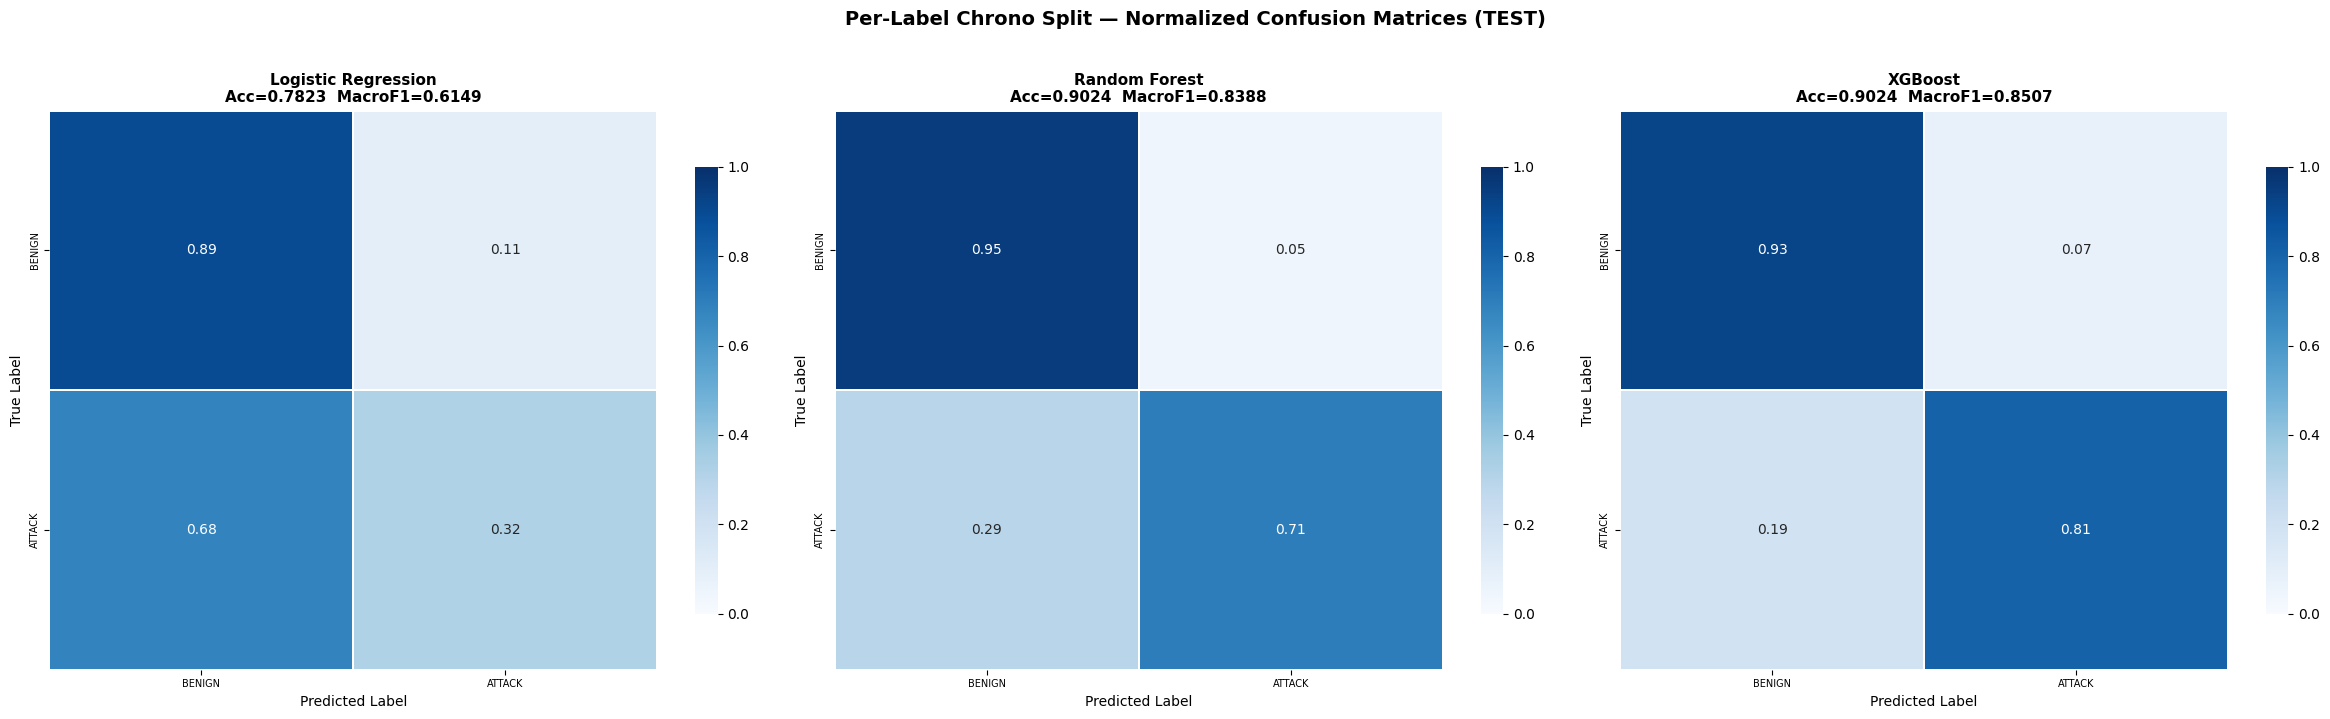

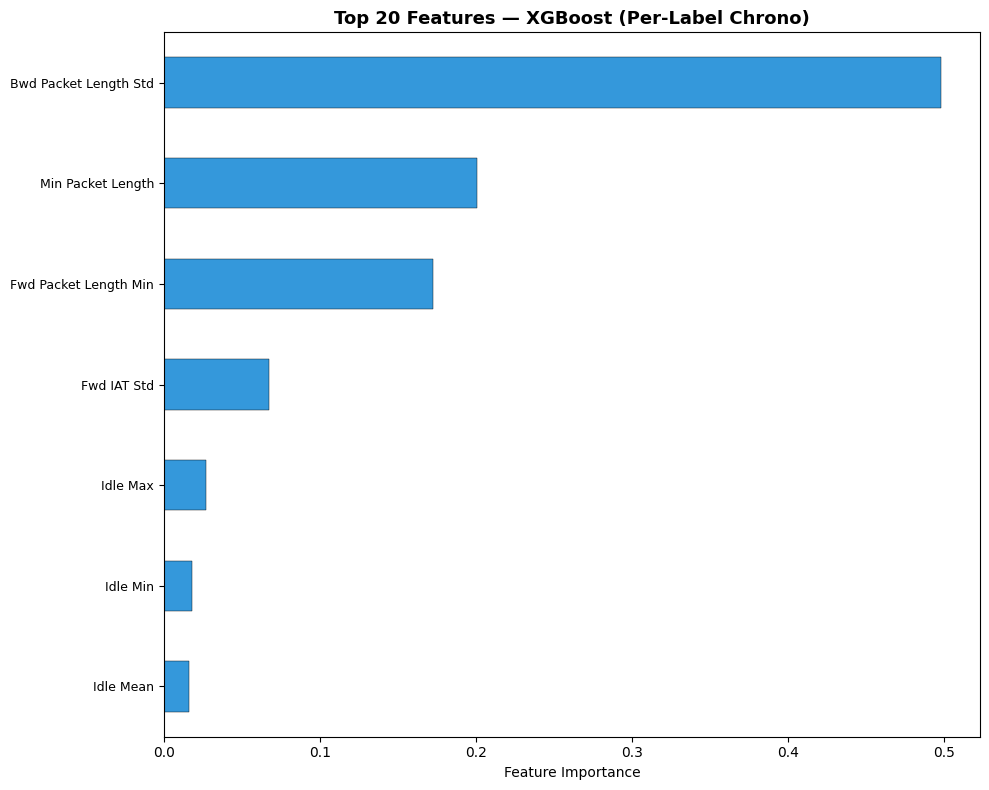

Per-Label Chrono Split — Summary

              Model Device Accuracy Weighted F1 Macro F1 Train Time (s) Val Accuracy Val Macro F1
Logistic Regression    GPU   0.7823      0.7701   0.6149            0.1       0.8802       0.7971
      Random Forest    GPU   0.9024      0.9007   0.8388            2.1       0.9613       0.9398
            XGBoost    GPU   0.9024      0.9044   0.8507            0.9       0.9652       0.9462

XGBoost baseline results saved to prepared_data/xgb_baseline_results.npz


In [22]:
if sections_cfg.run_label_stratified:
    show_reports(ls_results, y_test_ls, ls_class_names)
    show_confusion_matrices(ls_results, y_test_ls, ls_class_names, 'Per-Label Chrono Split — Normalized Confusion Matrices (TEST)')
    show_feature_importance(ls_trained_models, active_feature_cols, '(Per-Label Chrono)')
    s14_summary = show_summary(ls_results, ls_class_names, 'Per-Label Chrono Split — Summary')

    # Save XGBoost baseline results for reuse in 03_graph_ml.ipynb
    if 'XGBoost' in ls_results:
        xgb_res = ls_results['XGBoost']
        np.savez(
            os.path.join(data_cfg.prepared_data_dir, 'xgb_baseline_results.npz'),
            test_preds=xgb_res['y_pred'],
            accuracy=np.float64(xgb_res['accuracy']),
            f1_macro=np.float64(xgb_res['f1_macro']),
            f1_weighted=np.float64(xgb_res['f1_weighted']),
            train_time=np.float64(xgb_res['train_time']),
        )
        print(f"\nXGBoost baseline results saved to {data_cfg.prepared_data_dir}/xgb_baseline_results.npz")

---
## Cross-Section Comparison

In [23]:
print("=" * 80)
print("Cross-Section Comparison - XGBoost Test Metrics")
print("=" * 80)

cross_rows = []

all_sections = [
    ('Balanced Binary (Random)', sections_cfg.run_balanced, lambda: bal_results),
    ('Temporal (Mon-Thu/Fri)', sections_cfg.run_temporal, lambda: ts_results),
    ('Day-Stratified 70/30', sections_cfg.run_day_stratified, lambda: ds_results),
    ('Chronological 70/15/15', sections_cfg.run_chronological, lambda: cs_results),
    ('Per-Label Chrono 70/15/15', sections_cfg.run_label_stratified, lambda: ls_results),
]

for sec_name, enabled, get_results in all_sections:
    if enabled:
        sec_res = get_results()
        if 'XGBoost' in sec_res:
            m = sec_res['XGBoost']
            cross_rows.append({
                'Section': sec_name,
                'Accuracy': f"{m['accuracy']:.4f}",
                'Macro F1': f"{m['f1_macro']:.4f}",
                'Weighted F1': f"{m['f1_weighted']:.4f}",
            })

if cross_rows:
    cross_df = pd.DataFrame(cross_rows)
    print(cross_df.to_string(index=False))
else:
    print("No sections were run.")

Cross-Section Comparison - XGBoost Test Metrics
                  Section Accuracy Macro F1 Weighted F1
 Balanced Binary (Random)   0.9173   0.9171      0.9171
   Temporal (Mon-Thu/Fri)   0.7772   0.7465      0.7616
     Day-Stratified 70/30   0.9686   0.9584      0.9690
   Chronological 70/15/15   0.9536   0.8140      0.9536
Per-Label Chrono 70/15/15   0.9024   0.8507      0.9044
